<div style="background:linear-gradient(135deg,#000000 0%,#1a1a2e 100%);padding:36px 32px;border-radius:12px"><h1 style="color:#fff;margin:0 0 8px">Adidas Global Catalogue 2026</h1><p style="color:#FF6B35;font-weight:600">End-to-End Data Analysis &mdash; 10 Chapters &middot; 44,888 SKUs &middot; 10 Countries</p><div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:14px"><span style="background:rgba(255,255,255,0.1);color:#fff;padding:5px 12px;border-radius:20px;font-size:0.85em">EDA &amp; Visualisation</span><span style="background:rgba(255,255,255,0.1);color:#fff;padding:5px 12px;border-radius:20px;font-size:0.85em">Pricing Strategy</span><span style="background:rgba(255,255,255,0.1);color:#fff;padding:5px 12px;border-radius:20px;font-size:0.85em">10-Country Comparison</span><span style="background:rgba(255,255,255,0.1);color:#fff;padding:5px 12px;border-radius:20px;font-size:0.85em">ML Clustering &amp; Prediction</span></div></div>

<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #FF6B35;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 1 &mdash; Setup &amp; Data Loading</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Load CSVs &middot; FX normalisation &middot; Column cleaning</p></div>

In [1]:
%matplotlib inline

import warnings, glob, re
from collections import Counter
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

try:
    from wordcloud import WordCloud; WC_OK = True
except ImportError:
    WC_OK = False

try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    STOP_WORDS = set(stopwords.words('english'))
except Exception:
    STOP_WORDS = set()

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.cluster          import KMeans
from sklearn.decomposition    import PCA
from sklearn.ensemble         import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.metrics          import mean_absolute_error, r2_score, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

# ── Plotly renderer — guaranteed for Kaggle ──────────────────────────────────
pio.renderers.default = 'iframe'
if 'iframe' not in pio.renderers:
    pio.renderers.default = 'notebook'

# ── Adidas Design System ─────────────────────────────────────────────────────
C_BLACK  = '#000000'; C_ORANGE = '#FF6B35'; C_TEAL   = '#4ECDC4'
C_YELLOW = '#FFE66D'; C_MINT   = '#A8E6CF'; C_PINK   = '#FF8B94'
C_PURPLE = '#7C4DFF'; C_CYAN   = '#1DE9B6'; C_AMBER  = '#FF6D00'
C_SILVER = '#E8E8E8'
ADIDAS_COLORS = [C_BLACK, C_ORANGE, C_TEAL, C_YELLOW, C_MINT,
                 C_PINK, C_PURPLE, C_CYAN, C_AMBER, C_SILVER]
_adidas_cmap = LinearSegmentedColormap.from_list('adidas', ['#ffffff', C_ORANGE])

def _apply_plotly(fig, height=480, title=None):
    """Apply Adidas design to any Plotly figure."""
    upd = dict(
        height=height, paper_bgcolor='white', plot_bgcolor='#f9f9f9',
        font=dict(family='Arial, sans-serif', color='#2C2C2C'),
        title_font=dict(size=16, color='#000000'),
        margin=dict(t=70, b=60, l=60, r=40),
        hoverlabel=dict(bgcolor='white', font_size=12, bordercolor='#cccccc'),
    )
    if title: upd['title_text'] = title
    fig.update_layout(**upd)
    fig.update_xaxes(gridcolor='#eeeeee', linecolor='#cccccc')
    fig.update_yaxes(gridcolor='#eeeeee', linecolor='#cccccc')
    return fig

def _style_fig(fig, suptitle=None):
    """Apply consistent Adidas styling to a matplotlib figure."""
    fig.patch.set_facecolor('white')
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01, color='#111111')
    return fig

# Matplotlib global style
for _s in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot']:
    try: plt.style.use(_s); break
    except OSError: continue

plt.rcParams.update({
    'figure.dpi'        : 120,  'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#fafafa', 'axes.edgecolor' : '#dddddd',
    'axes.linewidth'    : 0.8,  'axes.spines.top'   : False,
    'axes.spines.right' : False,'axes.grid'          : True,
    'grid.color'        : '#eeeeee', 'grid.linewidth' : 0.6,
    'axes.titlesize'    : 13,   'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 10,   'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,    'legend.framealpha' : 0.85,
    'legend.edgecolor'  : '#dddddd', 'font.family'  : 'DejaVu Sans',
    'figure.titlesize'  : 14,   'figure.titleweight': 'bold',
})

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"Plotly renderer: {pio.renderers.default}")
print("Design system loaded: ADIDAS_COLORS, _apply_plotly(), _style_fig()")


pandas 2.3.3 | numpy 2.0.2 | matplotlib 3.10.0
Plotly renderer: iframe
Design system loaded: ADIDAS_COLORS, _apply_plotly(), _style_fig()


In [2]:
# ── Load ALL country CSV files from the Adidas Global Catalogue dataset ───────
# The dataset contains one CSV per country (BR_Adidas.csv, US_Adidas.csv, etc.)
# We load all of them and concatenate into one dataframe.

DATASET_PATH = '/kaggle/input/datasets/bsthere/adidas-global-catalogue-2026'

# Find all CSVs in the correct dataset folder
_paths = sorted(set(glob.glob(f'{DATASET_PATH}/**/*.csv', recursive=True) +
                glob.glob(f'{DATASET_PATH}/*.csv')))

# Fallback: search entire /kaggle/input if specific folder not found
if not _paths:
    _paths = sorted(set(glob.glob('/kaggle/input/**/*.csv', recursive=True)))

if not _paths:
    raise FileNotFoundError(
        "No CSV files found.\n"
        "Make sure the dataset is added via: Data > Add Data > "
        "search 'Adidas Global Catalogue 2026' by bsthere\n"
        f"Expected path: {DATASET_PATH}")

print(f"Found {len(_paths)} file(s):")
for p in _paths:
    print(f"  {p}")

# Load and concatenate all CSVs
_dfs = []
for p in _paths:
    try:
        _df = pd.read_csv(p, low_memory=False)
        _dfs.append(_df)
        print(f"  Loaded {p.split('/')[-1]:30s}  {_df.shape[0]:,} rows")
    except Exception as e:
        print(f"  WARNING — could not load {p}: {e}")

if not _dfs:
    raise ValueError("All files failed to load. Check file format.")

df_raw = pd.concat(_dfs, ignore_index=True)
print(f"\nCombined shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Countries found: {df_raw['country_code'].nunique() if 'country_code' in df_raw.columns else 'N/A'}")
print(f"Columns        : {list(df_raw.columns)}")


Found 11 file(s):
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/Adidas_Global.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/BR_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/CN_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/DE_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/FR_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/GB_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/IN_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/JP_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/KR_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/MX_Adidas.csv
  /kaggle/input/datasets/bsthere/adidas-global-catalogue-2026/US_Adidas.csv
  Loaded Adidas_Global.csv               44,888 rows
  Loaded BR_Adidas.csv                   4,680 rows
  Loaded CN_Adidas.csv               

In [3]:
# ── Data Preparation — column renaming + cleaning tailored to this dataset ────

# FX rates (approximate, as of Q1 2026, sourced Mar 2026) — update if rerunning later
FX_TO_USD = {
    'US': 1.000, 'GB': 1.280, 'DE': 1.090, 'FR': 1.090,
    'JP': 0.0067,'KR': 0.00074,'CN': 0.138, 'IN': 0.012,
    'MX': 0.052, 'BR': 0.200,
}

# Category normalisation — CSV has 53 multilingual variants
CATEGORY_MAP = {
    # Japanese
    'ライフスタイル':'Lifestyle', 'ランニング':'Running', 'サッカー':'Football',
    'バスケットボール':'Basketball', 'トレーニング':'Training', 'ゴルフ':'Golf',
    'アウトドア':'Outdoor', 'テニス':'Tennis',
    # German
    'Freizeit':'Lifestyle', 'Freiziet':'Lifestyle', 'Fußball':'Football',
    'Laufen':'Running', 'Schuhe':'Shoes', 'Bekleidung':'Apparel',
    'Wandern':'Hiking',
    # Spanish / Portuguese
    'Futebol':'Football', 'Fútbol':'Football', 'Randonnée':'Hiking',
    'Fútbol Sala':'Football', 'Fitness et Training':'Training',
    'Chaussures':'Shoes', 'Sportswear':'Lifestyle',
    # English variants
    'Soccer':'Football', 'Workout':'Training',
    'Fitness & Training':'Training', 'Gym & Training':'Training',
    'Trail Running':'Running', "Sports d'hiver":'Winter Sports',
    'Originals':'Lifestyle',
}

# Gender normalisation
GENDER_MAP = {
    'M':'Men', 'W':'Women', 'K':'Kids', 'U':'Unisex',
    '中性':'Unisex', '男子':'Men', '女子':'Women', '男童':'Kids', '女童':'Kids',
}

df = df_raw.copy()

# ── Core column renames → standard names used throughout the notebook ─────────
df = df.rename(columns={
    'price_local'    : 'price_usd_local',   # keep original name
    'gender_segment' : 'gender_raw',
    'subcategory'    : 'sub_category',
    'country_code'   : 'country',
    'color_name'     : 'color',
    'rating_count'   : 'num_reviews',
})

# ── FX normalisation: price_usd ───────────────────────────────────────────────
# Map FX — unmapped countries get NaN; fall back to local price as-is
_fx_mapped = df['country'].map(FX_TO_USD)
df['price'] = (df['price_usd_local'] * _fx_mapped).round(2)
# Warn about any countries not in FX_TO_USD
_no_fx = df[_fx_mapped.isna()]['country'].unique()
if len(_no_fx): print(f"WARNING: No FX rate for {_no_fx} — price will be NaN for these rows")
df['sale_price'] = (df['sale_price_local'] * df['country'].map(FX_TO_USD)).round(2)

# ── Category normalisation ────────────────────────────────────────────────────
df['category'] = df['category'].replace(CATEGORY_MAP)
# Keep top 12 English categories; everything else -> 'Other'
_top_cats = df['category'].value_counts().head(12).index.tolist()
df['category'] = df['category'].where(df['category'].isin(_top_cats), other='Other')

# ── Gender normalisation ──────────────────────────────────────────────────────
df['gender'] = df['gender_raw'].replace(GENDER_MAP)

# ── Clean rating_count: -99 is a sentinel for "not enough reviews" ────────────
df['num_reviews'] = df['num_reviews'].where(df['num_reviews'] > 0, np.nan)

# ── Clean discount: negative values are data errors ──────────────────────────
df['discount_pct'] = df['discount_pct'].where(df['discount_pct'] >= 0, np.nan)

# ── In-stock boolean ──────────────────────────────────────────────────────────
df['in_stock'] = df['in_stock'].astype(str).str.lower().isin(['true','1','yes'])

# ── Availability clean ────────────────────────────────────────────────────────
df['availability'] = df['availability'].fillna('UNKNOWN')

print(f"Prepared shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nKey columns ready:")
for col, desc in [('price','USD price'), ('category','normalised category'),
                  ('gender','gender label'), ('country','country code'),
                  ('rating','customer rating'), ('num_reviews','review count'),
                  ('discount_pct','discount %'), ('in_stock','in stock flag')]:
    n_null = df[col].isnull().sum()
    print(f"  {col:15s}: {str(df[col].dtype):8s}  nulls={n_null:5,}")


Prepared shape: 89,776 rows x 38 columns

Key columns ready:
  price          : float64   nulls=    0
  category       : object    nulls=    0
  gender         : object    nulls=  732
  country        : object    nulls=    0
  rating         : float64   nulls=54,934
  num_reviews    : float64   nulls=54,958
  discount_pct   : float64   nulls=29,450
  in_stock       : bool      nulls=    0


In [4]:
# ── Structural preview ────────────────────────────────────────────────────────
print("="*65 + "\nFIRST 3 ROWS (key columns)\n" + "="*65)
display(df[['product_id','product_name','category','gender','country',
            'price','rating','discount_pct','in_stock']].head(3))

print("\n" + "="*65 + "\nSTATISTICAL SUMMARY\n" + "="*65)
display(df[['price','sale_price','rating','num_reviews','discount_pct','size_count']].describe())


FIRST 3 ROWS (key columns)


,product_id,product_name,category,gender,country,price,rating,discount_pct,in_stock
0,JC5389,AGASALHO COM CAPUZ BIG LOGO,Lifestyle,Men,BR,86.00,NaN,0.00,True
1,JC5389,AGASALHO COM CAPUZ BIG LOGO,Lifestyle,Men,BR,86.00,NaN,0.00,True
2,JC5389,AGASALHO COM CAPUZ BIG LOGO,Lifestyle,Men,BR,86.00,NaN,0.00,True



STATISTICAL SUMMARY


,price,sale_price,rating,num_reviews,discount_pct,size_count
count,89776.00,51940.00,34842.00,34818.00,60326.00,89776.00
mean,113.50,107.42,4.68,549.44,5.88,17.06
std,66.40,67.38,0.37,2304.44,12.80,8.69
min,7.63,7.63,1.00,1.00,0.00,1.00
25%,71.99,70.00,4.63,12.00,0.00,12.00
50%,106.86,95.46,4.74,42.00,0.00,17.00
75%,137.34,131.99,4.86,182.00,0.00,22.00
max,2599.95,2599.95,5.00,19686.00,60.00,73.00


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #4ECDC4;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 2 &mdash; Data Quality</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Missing values &middot; Duplicates &middot; Outlier analysis</p></div>

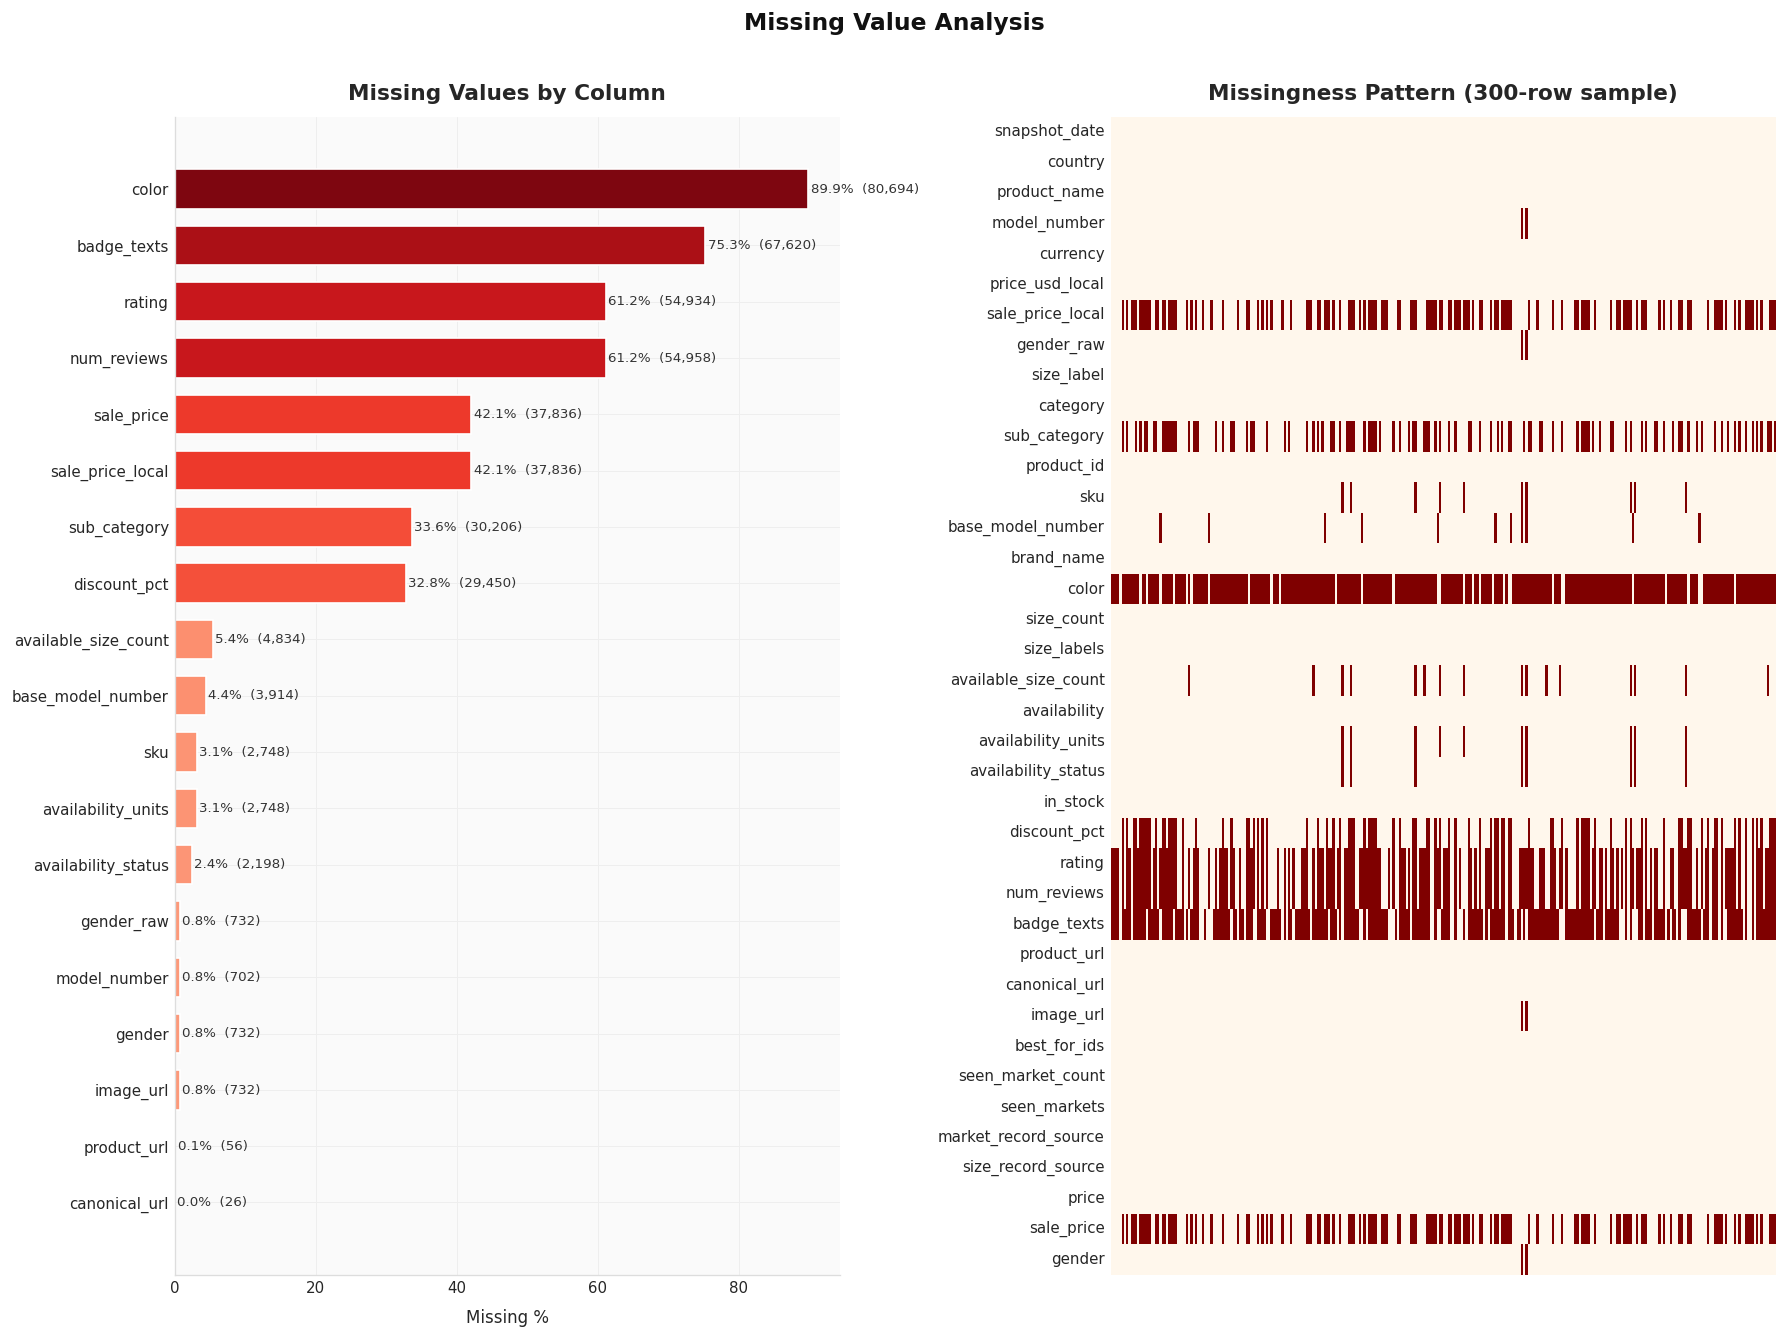

,Count,Pct
color,"80,694",89.9%
badge_texts,"67,620",75.3%
rating,"54,934",61.2%
num_reviews,"54,958",61.2%
sale_price,"37,836",42.1%
sale_price_local,"37,836",42.1%
sub_category,"30,206",33.6%
discount_pct,"29,450",32.8%
available_size_count,"4,834",5.4%
base_model_number,"3,914",4.4%


In [5]:
# ── 2.1  Missing Values ───────────────────────────────────────────────────────
missing  = df.isnull().sum()
miss_pct = (missing / len(df) * 100).round(1)
miss_df  = (pd.DataFrame({'Count': missing, 'Pct': miss_pct})
              .query('Count > 0').sort_values('Pct', ascending=False))

if miss_df.empty:
    print("No missing values.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(miss_df)*0.5 + 1.5)))
    _style_fig(fig, 'Missing Value Analysis')
    vals = miss_df['Pct'].values
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    clrs = [plt.cm.Reds(0.35 + 0.6*n) for n in norm]
    bars = axes[0].barh(miss_df.index, vals, color=clrs, edgecolor='white', height=0.7)
    axes[0].set_xlabel('Missing %', labelpad=8); axes[0].set_title('Missing Values by Column', pad=10)
    axes[0].invert_yaxis(); axes[0].set_facecolor('#fafafa')
    for bar, (_, row) in zip(bars, miss_df.iterrows()):
        axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                     f"{row['Pct']:.1f}%  ({int(row['Count']):,})", va='center', fontsize=8, color='#333')
    _s = df.isnull().sample(min(300, len(df)), random_state=42)
    sns.heatmap(_s.T, cbar=False, cmap='OrRd', ax=axes[1], xticklabels=False, linewidths=0)
    axes[1].set_title('Missingness Pattern (300-row sample)', pad=10); axes[1].set_ylabel('')
    plt.tight_layout(); plt.show(); plt.close('all')
    display(miss_df.head(20).style
            .background_gradient(subset=['Pct'], cmap='Reds', vmin=0)
            .format({'Count': '{:,}', 'Pct': '{:.1f}%'}))


In [6]:
# ── 2.2  Duplicate Detection ──────────────────────────────────────────────────
# Note: same product_id can appear multiple times (one row per country × size)
full_dupes = df.duplicated().sum()
# True duplicates: same product + country + size
sku_dupes  = df.duplicated(subset=['product_id','country','size_label']).sum()

print(f"Full-row duplicates              : {full_dupes:,}")
print(f"Duplicate product+country+size   : {sku_dupes:,}")

# For analysis, work at product level (one row per product_id × country)
df_prod = (df.groupby(['product_id','country'])
             .agg(
                 product_name   = ('product_name',  'first'),
                 category       = ('category',       'first'),
                 sub_category   = ('sub_category',   'first'),
                 gender         = ('gender',          'first'),
                 price          = ('price',           'min'),
                 sale_price     = ('sale_price',      'min'),
                 discount_pct   = ('discount_pct',    'max'),
                 rating         = ('rating',          'mean'),
                 num_reviews    = ('num_reviews',     'max'),
                 in_stock       = ('in_stock',        'any'),
                 size_count     = ('size_count',      'first'),
                 seen_market_count = ('seen_market_count','first'),
                 color             = ('color',            'first'),
             )
             .reset_index())

print(f"\nProduct-level df: {df_prod.shape[0]:,} rows x {df_prod.shape[1]} columns")
print(f"(Used for most analyses — avoids duplicate-row inflation)")


Full-row duplicates              : 1,374
Duplicate product+country+size   : 44,888

Product-level df: 3,561 rows x 15 columns
(Used for most analyses — avoids duplicate-row inflation)


In [7]:
# ── 2.3  Data Cleaning Summary ────────────────────────────────────────────────
print("Cleaning actions already applied in Chapter 1:")
print(f"  FX conversion: price_local -> price (USD)  |  median=${df_prod['price'].median():.2f}")
print(f"  Category normalisation: {df_raw['category'].nunique()} raw -> {df['category'].nunique()} clean")
_raw_gender_col = 'gender_segment' if 'gender_segment' in df_raw.columns else 'gender_raw'
print(f"  Gender mapping: {df_raw[_raw_gender_col].nunique()} raw -> {df['gender'].nunique()} clean")
print(f"  rating_count -99 sentinel -> NaN  |  valid reviews: {df['num_reviews'].notna().sum():,}")
print(f"  discount_pct negatives -> NaN     |  valid discounts: {df['discount_pct'].notna().sum():,}")

# Additional: remove any remaining extreme price outliers (likely FX errors)
p1, p99 = df_prod['price'].quantile([0.01, 0.99])  # 1st and 99th percentiles
n_extreme = ((df_prod['price'] < p1) | (df_prod['price'] > p99*3)).sum()
print(f"  Extreme prices (outside 1-99th pctile x3): {n_extreme:,} flagged (not removed)")

print(f"\nFinal product-level dataset: {df_prod.shape[0]:,} rows x {df_prod.shape[1]} columns")


Cleaning actions already applied in Chapter 1:
  FX conversion: price_local -> price (USD)  |  median=$90.00
  Category normalisation: 53 raw -> 13 clean
  Gender mapping: 9 raw -> 4 clean
  rating_count -99 sentinel -> NaN  |  valid reviews: 34,818
  discount_pct negatives -> NaN     |  valid discounts: 60,326
  Extreme prices (outside 1-99th pctile x3): 36 flagged (not removed)

Final product-level dataset: 3,561 rows x 15 columns


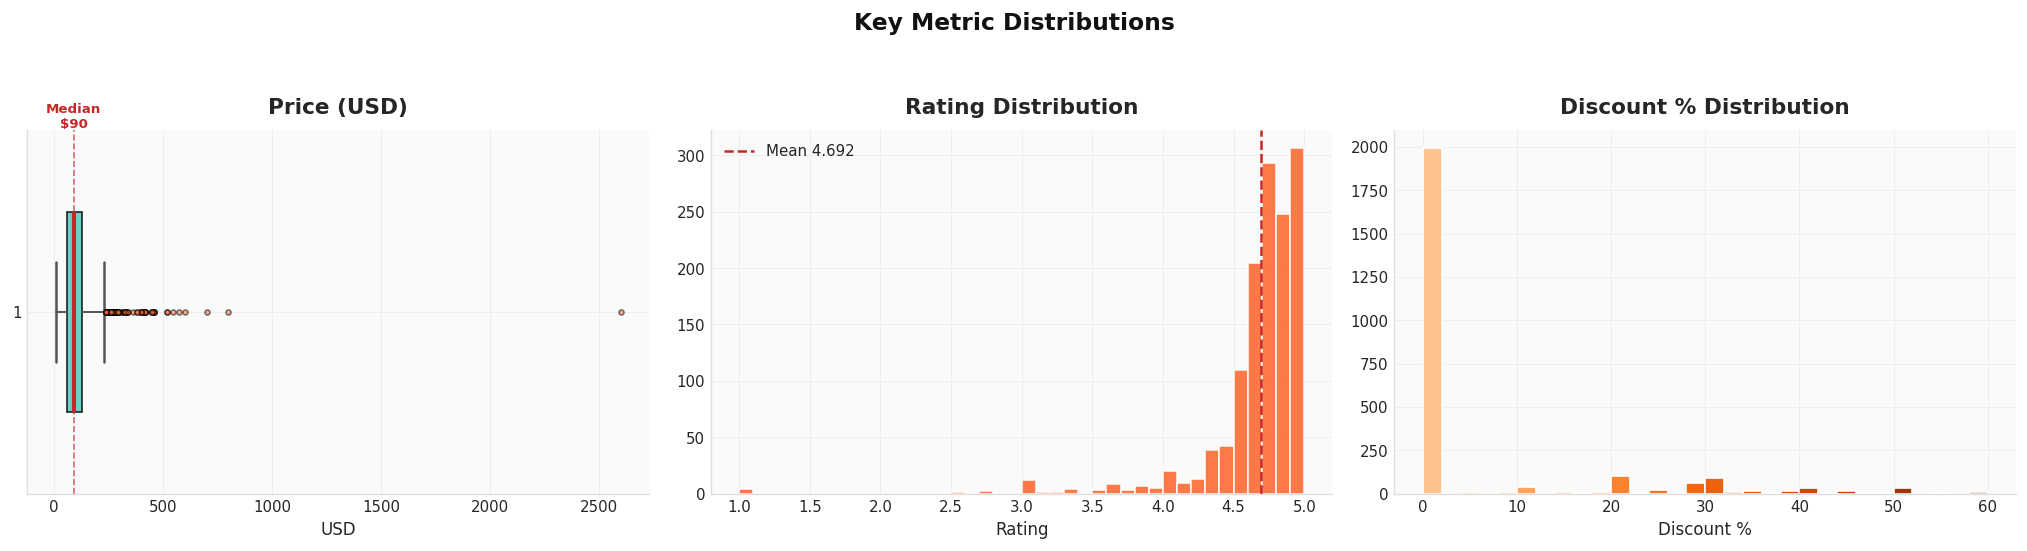

  Price  min=$7.63  median=$90.00  max=$2599.95
  Rating min=1.00  median=4.77  max=5.00  null=2,224
  Disc%  min=0.0  median=0.0  max=60.0  null=1,084


In [8]:
# ── 2.4  Outlier Detection ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
_style_fig(fig, 'Key Metric Distributions')

bp = axes[0].boxplot(df_prod['price'].dropna(), vert=False, patch_artist=True, widths=0.55,
                     boxprops=dict(facecolor=C_TEAL, alpha=0.85),
                     medianprops=dict(color='#c62828', lw=2.5),
                     whiskerprops=dict(color='#555', lw=1.2), capprops=dict(color='#555', lw=1.5),
                     flierprops=dict(marker='o', markerfacecolor=C_ORANGE, markersize=3, alpha=0.5))
axes[0].set_title('Price (USD)', pad=10); axes[0].set_xlabel('USD'); axes[0].set_facecolor('#fafafa')
med = df_prod['price'].median()
axes[0].axvline(med, color='#c62828', ls='--', lw=1, alpha=0.7)
axes[0].annotate(f'Median\n${med:.0f}',
                 xy=(med, 0.98), xycoords=('data','axes fraction'),
                 ha='center', fontsize=8, color='#c62828', fontweight='bold',
                 xytext=(0, 6), textcoords='offset points')

axes[1].hist(df_prod['rating'].dropna(), bins=40, color=C_ORANGE, edgecolor='white', lw=0.4, alpha=0.9)
axes[1].axvline(df_prod['rating'].mean(), color='#c62828', ls='--', lw=1.5,
                label=f"Mean {df_prod['rating'].mean():.3f}")
axes[1].set_title('Rating Distribution', pad=10); axes[1].set_xlabel('Rating')
axes[1].legend(); axes[1].set_facecolor('#fafafa')

n, bins_d, patches = axes[2].hist(df_prod['discount_pct'].dropna(), bins=30, edgecolor='white', lw=0.4)
for patch, b in zip(patches, bins_d[:-1]):
    patch.set_facecolor(plt.cm.Oranges(0.3 + 0.7*(b/(bins_d[-1]+1e-9))))
axes[2].set_title('Discount % Distribution', pad=10); axes[2].set_xlabel('Discount %'); axes[2].set_facecolor('#fafafa')

plt.tight_layout(rect=[0,0,1,0.96]); plt.show(); plt.close('all')
print(f"  Price  min=${df_prod['price'].min():.2f}  median=${df_prod['price'].median():.2f}  max=${df_prod['price'].max():.2f}")
print(f"  Rating min={df_prod['rating'].min():.2f}  median={df_prod['rating'].median():.2f}  max={df_prod['rating'].max():.2f}  null={df_prod['rating'].isnull().sum():,}")
print(f"  Disc%  min={df_prod['discount_pct'].min():.1f}  median={df_prod['discount_pct'].median():.1f}  max={df_prod['discount_pct'].max():.1f}  null={df_prod['discount_pct'].isnull().sum():,}")


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #FFE66D;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 3 &mdash; Exploratory Data Analysis</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Distributions &middot; Price by category &middot; Correlation</p></div>

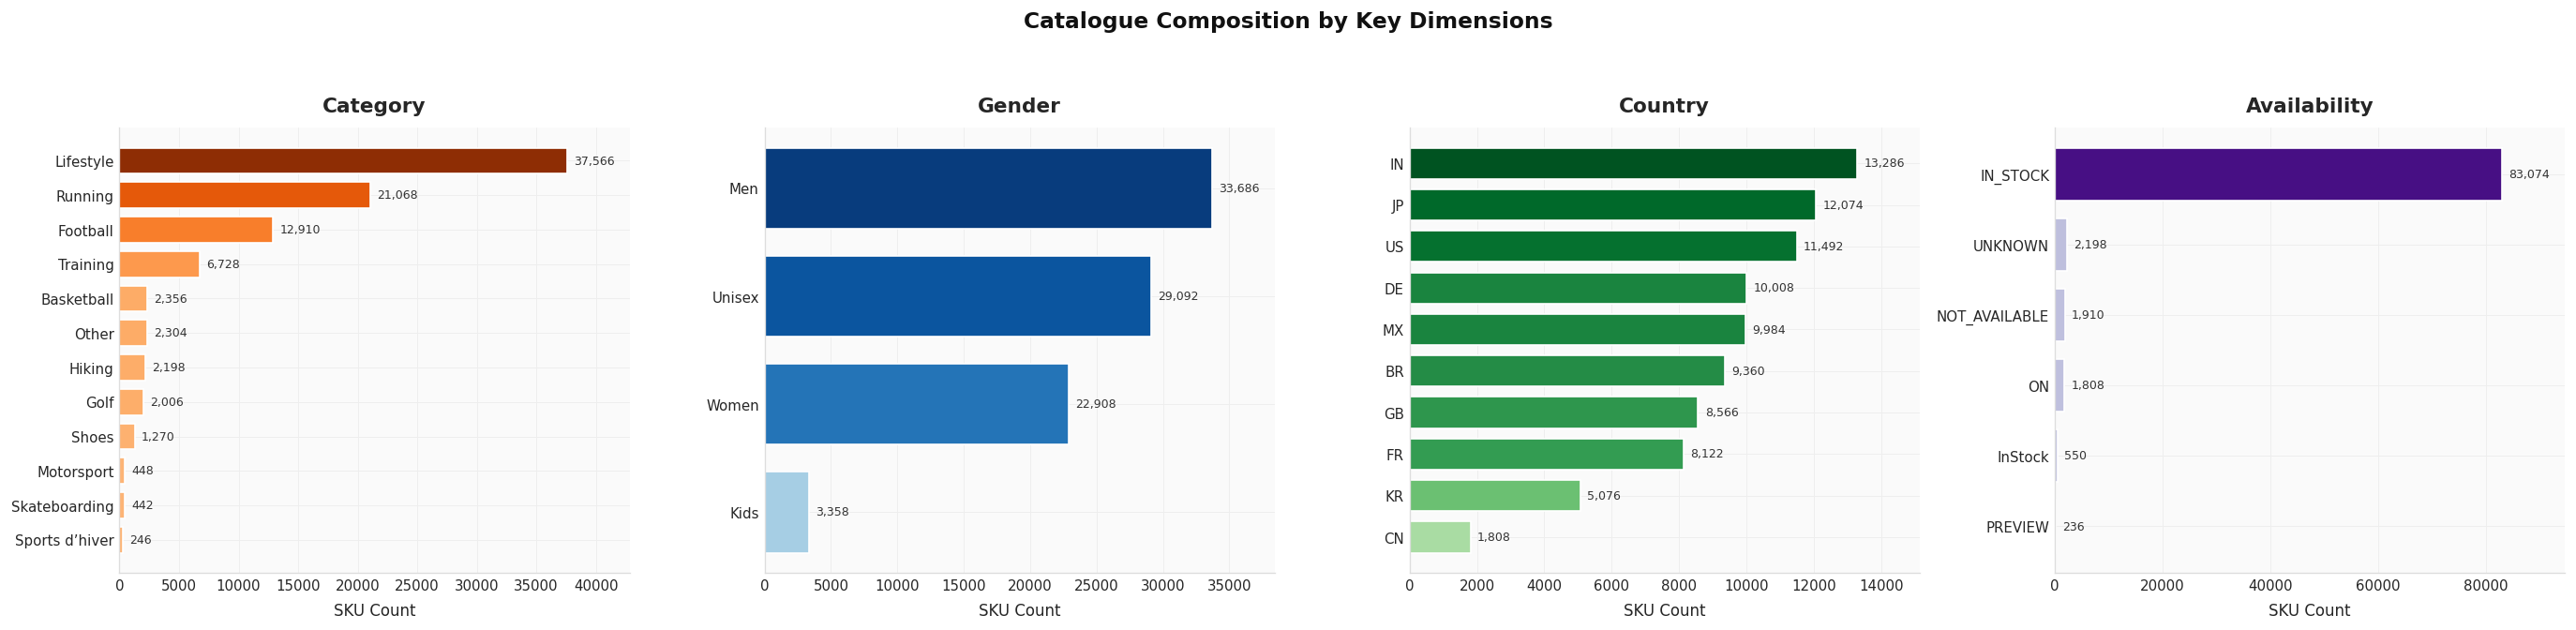

In [9]:
# ── 3.1  Univariate — Key Categorical Columns ─────────────────────────────────
_plot_cols = [('category','Category','Oranges'),('gender','Gender','Blues'),
              ('country','Country','Greens'),('availability','Availability','Purples')]

fig, axes = plt.subplots(1, 4, figsize=(23, 5.5))
_style_fig(fig, 'Catalogue Composition by Key Dimensions')

for ax, (col, title, cmap) in zip(axes, _plot_cols):
    top  = df[col].value_counts().dropna().head(12)
    vals = top.values.astype(float)
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    clrs = [plt.get_cmap(cmap)(0.35 + 0.6*n) for n in norm]
    bars = ax.barh(top.index.astype(str), vals, color=clrs, edgecolor='white', height=0.75)
    ax.invert_yaxis(); ax.set_title(title, pad=10); ax.set_xlabel('SKU Count', labelpad=6)
    xm = vals.max()
    for bar, v in zip(bars, vals):
        ax.text(v + xm*0.015, bar.get_y()+bar.get_height()/2,
                f'{int(v):,}', va='center', fontsize=7.5, color='#333')
    ax.set_xlim(right=xm*1.14); ax.set_facecolor('#fafafa')

plt.tight_layout(rect=[0,0,1,0.96]); plt.show(); plt.close('all')


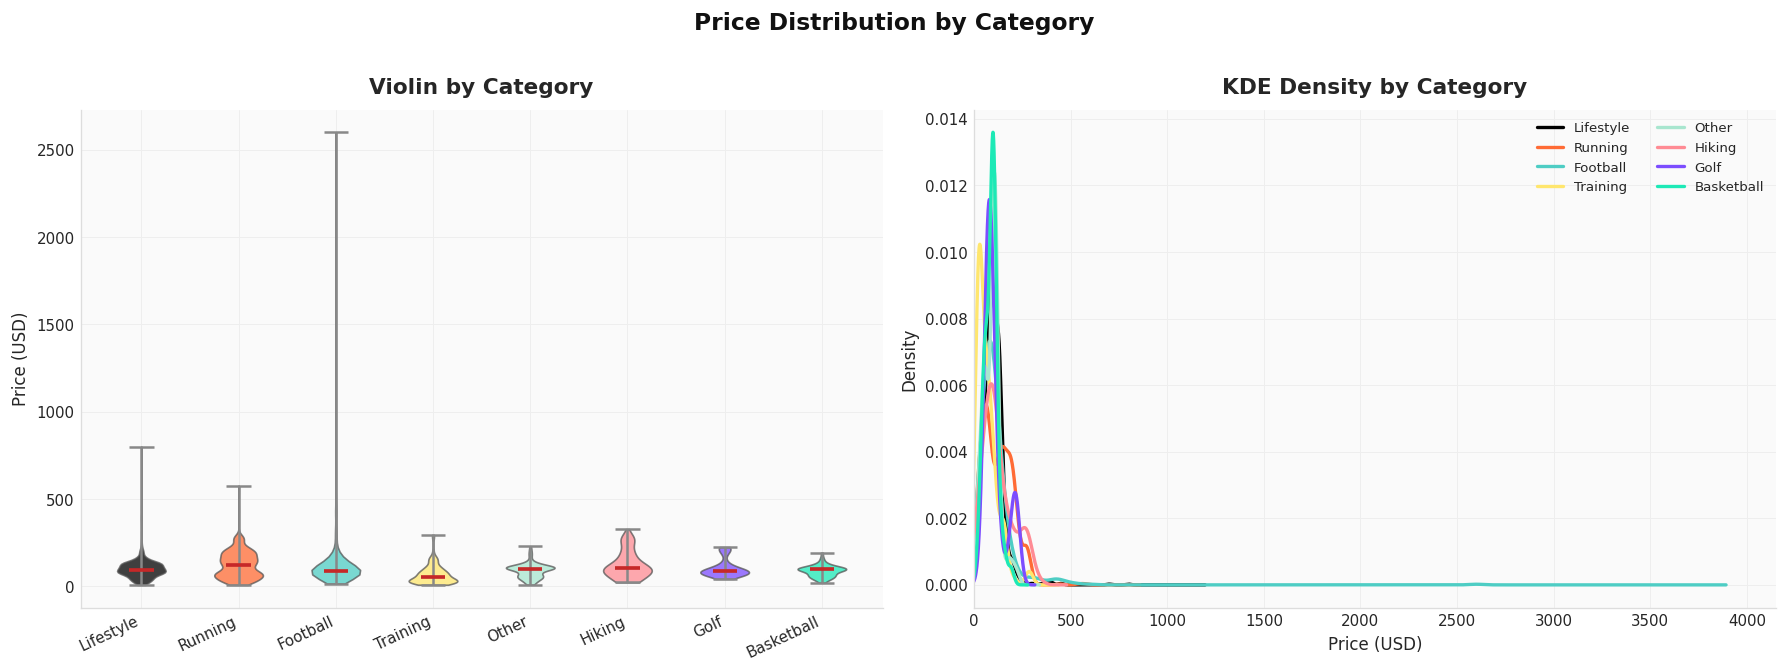

In [10]:
# ── 3.2  Price Distribution by Category ──────────────────────────────────────
cats = [c for c in df_prod['category'].value_counts().head(8).index
         if df_prod[df_prod['category']==c]['price'].dropna().shape[0] >= 10]

if not cats:
    print("Not enough data per category for violin/KDE.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    _style_fig(fig, 'Price Distribution by Category')

    data = [df_prod[df_prod['category']==c]['price'].dropna().values for c in cats]
    vp   = axes[0].violinplot(data, showmedians=True)
    for k, pc in enumerate(vp['bodies']):
        pc.set_facecolor(ADIDAS_COLORS[k % len(ADIDAS_COLORS)]); pc.set_alpha(0.75); pc.set_edgecolor('#555')
    vp['cmedians'].set_color('#c62828'); vp['cmedians'].set_linewidth(2.2)
    for key in ('cbars','cmaxes','cmins'):
        if key in vp: vp[key].set_color('#888')
    axes[0].set_xticks(range(1, len(cats)+1))
    axes[0].set_xticklabels(cats, rotation=25, ha='right', fontsize=9)
    axes[0].set_ylabel('Price (USD)'); axes[0].set_title('Violin by Category', pad=10); axes[0].set_facecolor('#fafafa')

    for k, cat in enumerate(cats):
        df_prod[df_prod['category']==cat]['price'].dropna().plot.kde(
            ax=axes[1], label=cat, color=ADIDAS_COLORS[k % len(ADIDAS_COLORS)], lw=2)
    axes[1].set_xlim(left=0); axes[1].set_xlabel('Price (USD)')
    axes[1].set_title('KDE Density by Category', pad=10); axes[1].legend(fontsize=8, ncol=2)
    axes[1].set_facecolor('#fafafa')
    plt.tight_layout(); plt.show(); plt.close('all')


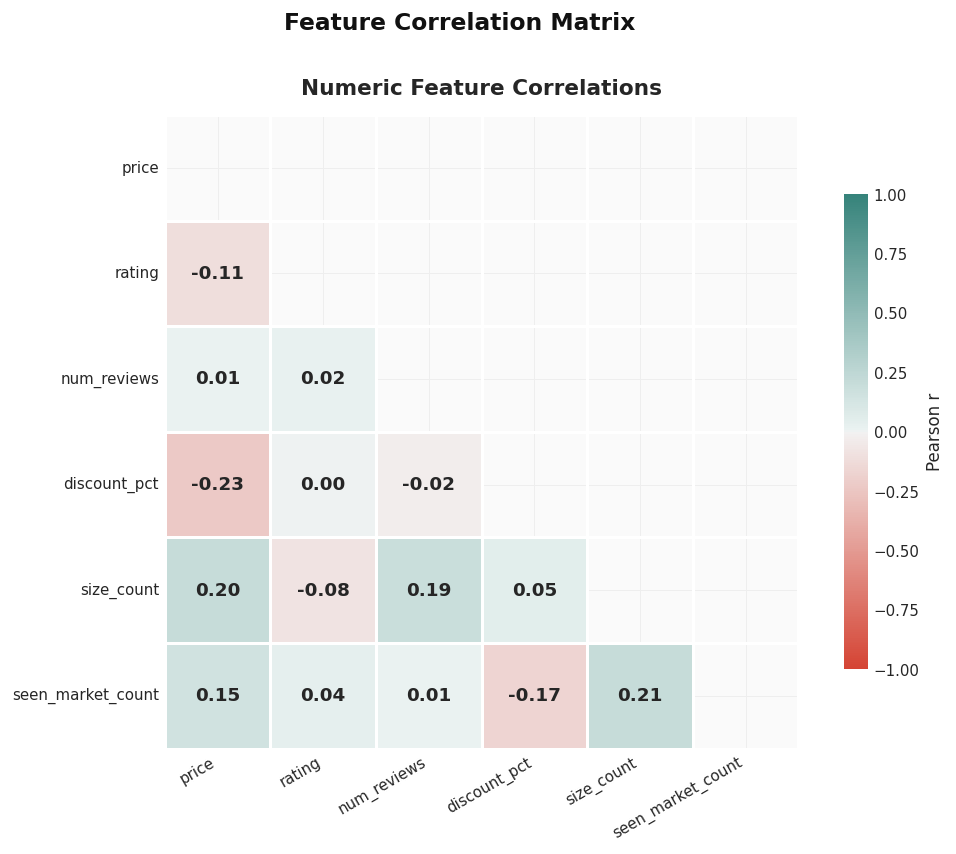

In [11]:
# ── 3.3  Correlation Heatmap ──────────────────────────────────────────────────
num_df = df_prod[['price','rating','num_reviews','discount_pct','size_count','seen_market_count']].copy()
corr   = num_df.corr(min_periods=30)
mask   = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
_style_fig(fig, 'Feature Correlation Matrix')
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(15, 180, s=80, l=50, as_cmap=True),
            center=0, vmin=-1, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, square=True, ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.set_title('Numeric Feature Correlations', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_facecolor('#fafafa')
plt.tight_layout(); plt.show(); plt.close('all')


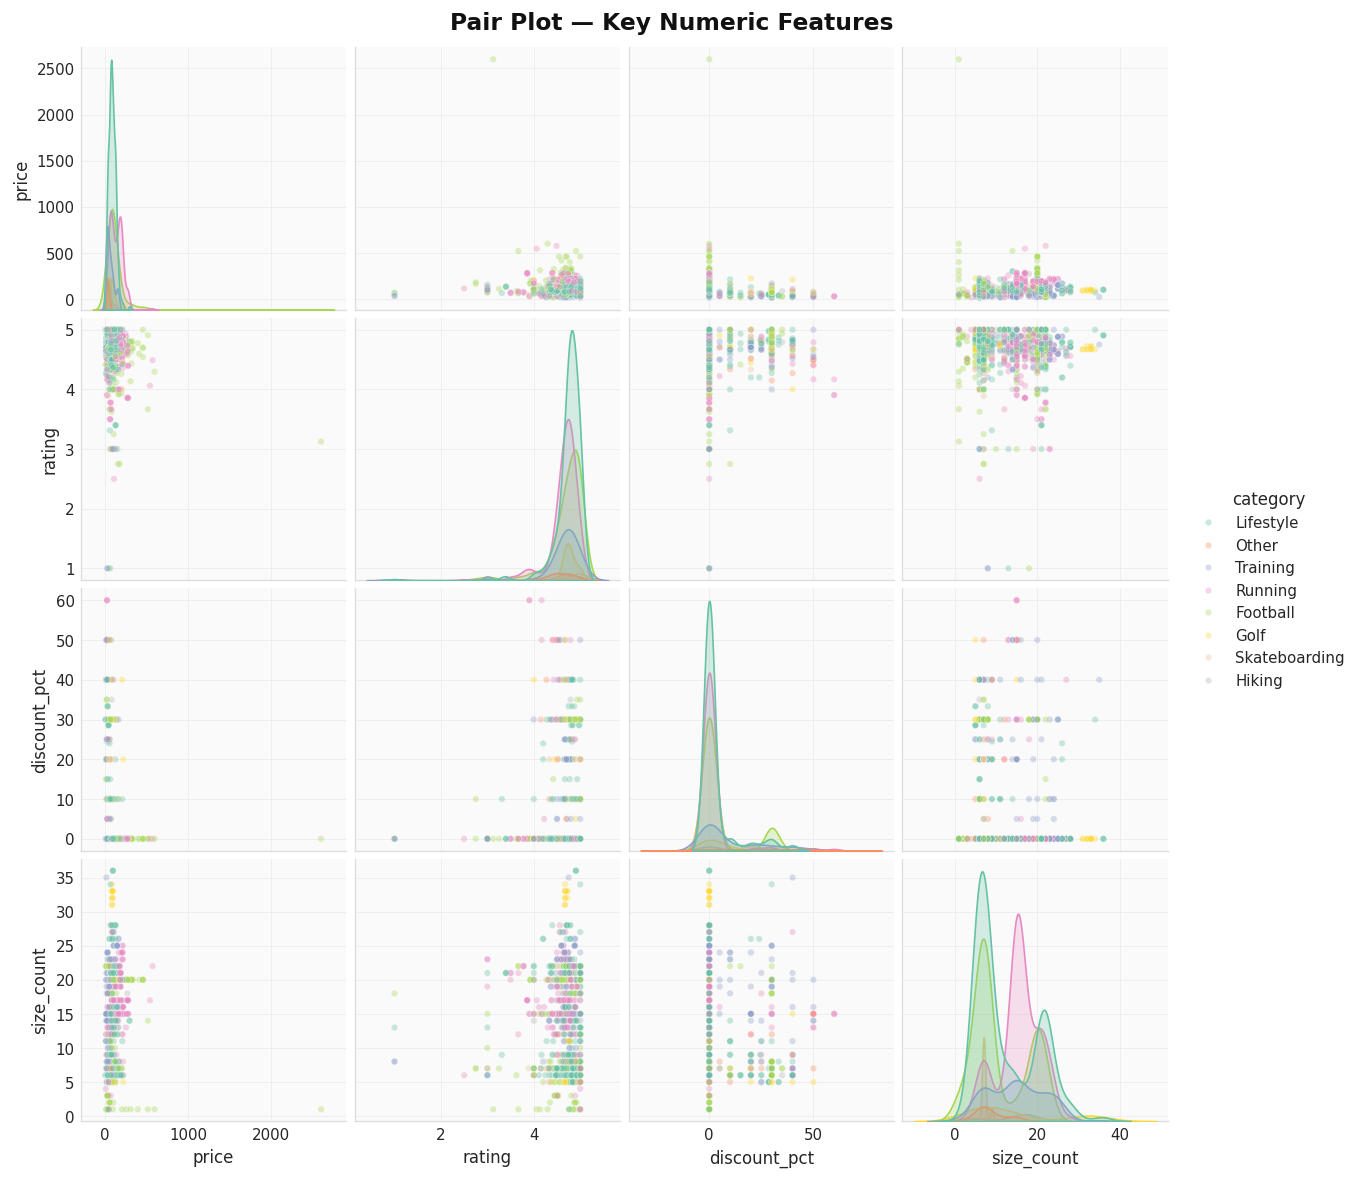

In [12]:
# ── 3.4  Pair Plot (sampled) ──────────────────────────────────────────────────
_cols  = ['price','rating','discount_pct','size_count','category']
# Fill discount_pct NaN as 0 (no discount) so most rows are kept
_pdf   = df_prod[_cols].copy()
_pdf['discount_pct'] = _pdf['discount_pct'].fillna(0)
_pdf   = _pdf.dropna()  # only drops rows where price/rating/size_count are missing
if len(_pdf) > 1500: _pdf = _pdf.sample(1500, random_state=42)

# Limit hue to top-8 categories — Set2 only has 8 colours
_top8 = _pdf['category'].value_counts().head(8).index.tolist()
_pdf_pp = _pdf[_pdf['category'].isin(_top8)]
g = sns.pairplot(_pdf_pp, hue='category', diag_kind='kde',
                 plot_kws={'alpha':0.35,'s':15}, palette='Set2')
g.fig.suptitle('Pair Plot — Key Numeric Features', fontweight='bold', color='#111111', fontsize=14)
g.fig.subplots_adjust(top=0.95)
plt.show(); plt.close('all')


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #A8E6CF;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 4 &mdash; Product Portfolio Deep-Dive</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Sunburst &middot; Gender heatmap &middot; Country comparison</p></div>

In [13]:
# ── 4.1  Portfolio Structure — Interactive Sunburst ───────────────────────────
_sb = df_prod.dropna(subset=['category','gender']).copy()
_sb['_count'] = 1

fig = px.sunburst(
    _sb, path=['category','gender'], values='_count', color='category',
    color_discrete_sequence=px.colors.qualitative.Bold,
    title='Product Portfolio Structure — Category > Gender (SKU Count)',
    branchvalues='total',
)
fig.update_traces(
    textfont_size=12, insidetextorientation='radial',
    hovertemplate='<b>%{label}</b><br>SKUs: %{value:,}<br>%{percentParent:.1%} of parent<extra></extra>',
    marker=dict(line=dict(color='white', width=1.5))
)
_apply_plotly(fig, height=600)
fig.update_layout(paper_bgcolor='white', margin=dict(t=70, l=10, r=10, b=10))
fig.show()


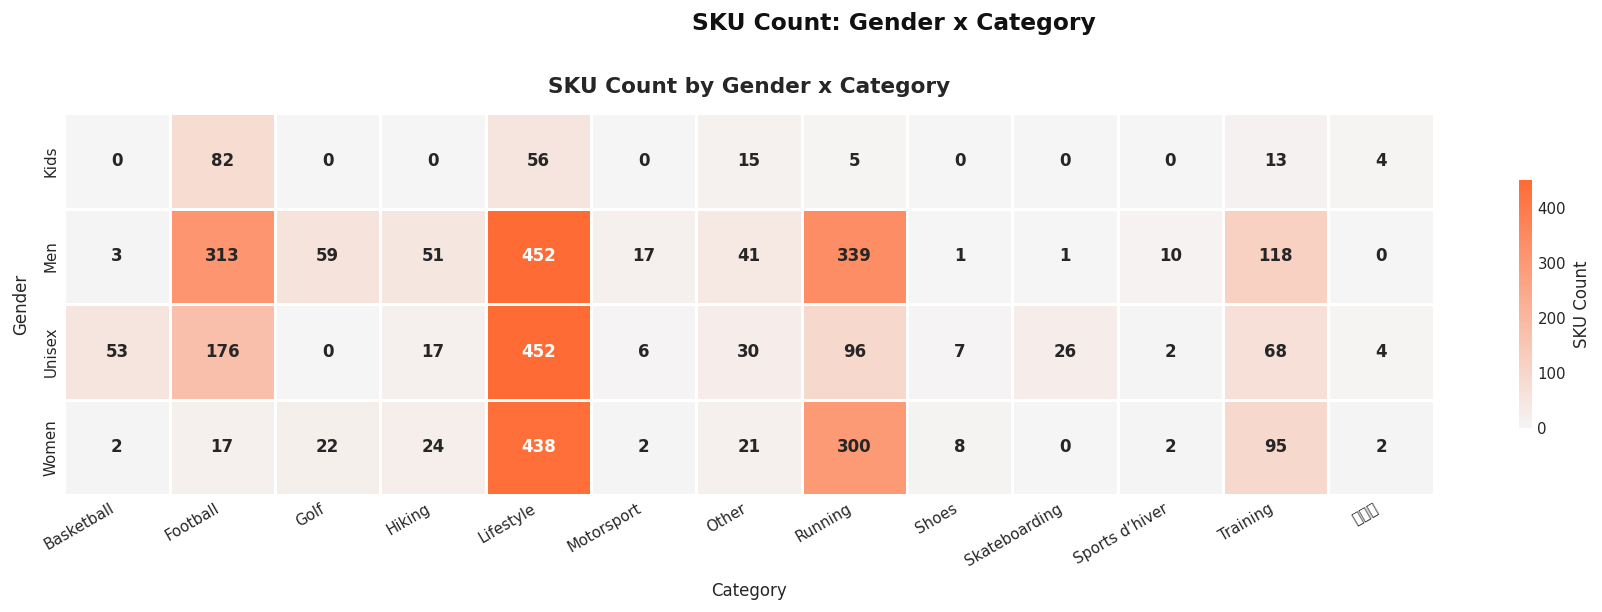

In [14]:
# ── 4.2  Gender x Category Heat-Map ──────────────────────────────────────────
pivot = df_prod.pivot_table(index='gender', columns='category', aggfunc='size', fill_value=0)
fig, ax = plt.subplots(figsize=(15, 5))
_style_fig(fig, 'SKU Count: Gender x Category')
_cmap_hm = LinearSegmentedColormap.from_list('ag', ['#f5f5f5', C_ORANGE])
sns.heatmap(pivot, annot=True, fmt='d', cmap=_cmap_hm,
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'}, ax=ax,
            cbar_kws={'shrink': 0.65, 'label': 'SKU Count'})
ax.set_title('SKU Count by Gender x Category', pad=12)
ax.set_xlabel('Category', labelpad=8); ax.set_ylabel('Gender', labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_facecolor('#fafafa')
plt.tight_layout(); plt.show(); plt.close('all')


In [15]:
# ── 4.3  Country Analysis ────────────────────────────────────────────────────
ctry = (df_prod.groupby('country')
               .agg(products=('product_id','nunique'),avg_price=('price','mean'),avg_rating=('rating','mean'))
               .reset_index().sort_values('products', ascending=False))

fig = make_subplots(rows=1, cols=2, subplot_titles=['Unique Products per Country','Avg Price (USD)'])
_n1 = (ctry['products'] - ctry['products'].min()) / (ctry['products'].max() - ctry['products'].min() + 1)
_c1 = [f'rgba({int(255*(1-n))},{int(107+148*n)},{int(53+200*n)},0.9)' for n in _n1]
_n2 = (ctry['avg_price'] - ctry['avg_price'].min()) / (ctry['avg_price'].max() - ctry['avg_price'].min() + 1)
_c2 = [f'rgba({int(20+235*n)},{int(107*(1-n))},{int(53*(1-n))},0.9)' for n in _n2]
fig.add_trace(go.Bar(x=ctry['country'], y=ctry['products'], marker_color=_c1,
                     text=ctry['products'].apply(lambda x: f'{x:,}'), textposition='outside',
                     hovertemplate='<b>%{x}</b><br>Products: %{y:,}<extra></extra>'), row=1, col=1)
fig.add_trace(go.Bar(x=ctry['country'], y=ctry['avg_price'].round(1), marker_color=_c2,
                     text=ctry['avg_price'].round(0).apply(lambda x: f'${x:.0f}'), textposition='outside',
                     hovertemplate='<b>%{x}</b><br>Avg Price: $%{y:.2f}<extra></extra>'), row=1, col=2)
_apply_plotly(fig, height=450, title='Country Portfolio Overview')
fig.update_layout(showlegend=False, bargap=0.25)
fig.show()


SKUs with colour data: 9,082 / 89,776 (10.1%)


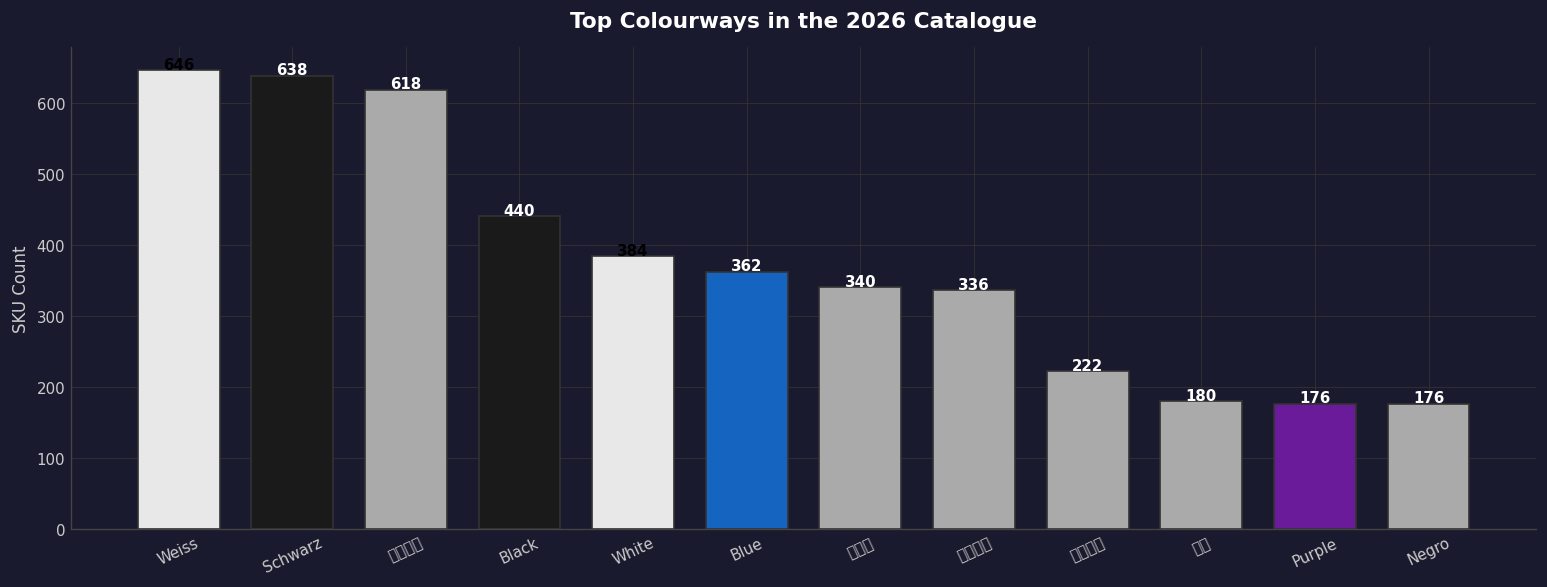

In [16]:
# ── 4.4  Colour Trend Analysis ────────────────────────────────────────────────
col_valid = df['color'].dropna()
print(f"SKUs with colour data: {len(col_valid):,} / {len(df):,} ({len(col_valid)/len(df)*100:.1f}%)")

if len(col_valid) < 5:
    print("Not enough colour data to plot.")
else:
    top_col = col_valid.value_counts().head(12)
    HEX = {'Black':'#1a1a1a','Schwarz':'#1a1a1a','Weiss':'#e8e8e8','White':'#e8e8e8',
            'Blue':'#1565C0','Red':'#C62828','Green':'#2E7D32','Yellow':'#F9A825',
            'Purple':'#6A1B9A','Grey':'#888888','Brown':'#4E342E','Beige':'#c8b89a',
            'Orange':'#E65100','Pink':'#E91E8C'}
    clrs = [HEX.get(str(c),'#AAAAAA') for c in top_col.index]

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#1a1a2e'); ax.set_facecolor('#1a1a2e')
    ax.set_title('Top Colourways in the 2026 Catalogue', color='white', fontsize=13, fontweight='bold', pad=12)
    bars = ax.bar(top_col.index.astype(str), top_col.values,
                  color=clrs, edgecolor='#333', linewidth=1.0, width=0.72)
    ax.set_ylabel('SKU Count', color='#ccc'); ax.tick_params(colors='#ccc', axis='both')
    ax.tick_params(axis='x', rotation=25); ax.grid(color='#333', linewidth=0.5)
    ax.spines['bottom'].set_color('#444'); ax.spines['left'].set_color('#444')
    for bar, c in zip(bars, clrs):
        h = bar.get_height()
        tc = 'black' if c in ('#e8e8e8','#888888','#c8b89a','#F9A825') else 'white'
        ax.text(bar.get_x()+bar.get_width()/2, h+2, f'{int(h):,}',
                ha='center', fontsize=9, color=tc, fontweight='bold')
    plt.tight_layout(); plt.show(); plt.close('all')


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #FF8B94;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 5 &mdash; Pricing Strategy</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Price tiers &middot; Country comparison &middot; Discount analysis</p></div>

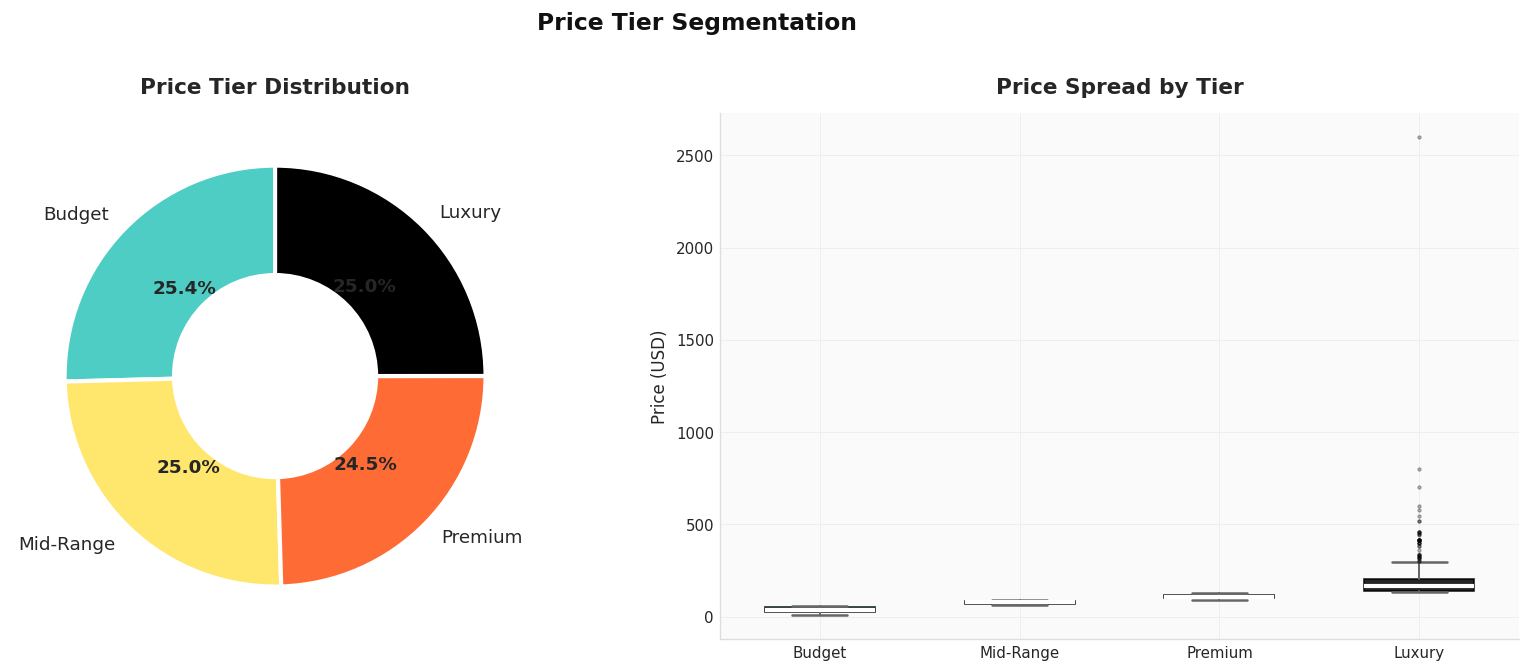

  Tier thresholds (USD):
    Budget      : $7.63  -  $60.00
    Mid-Range   : $60.00  -  $90.00
    Premium     : $90.00  -  $130.80
    Luxury      : $130.80  -  $2599.95


In [17]:
# ── 5.1  Price Tier Segmentation ─────────────────────────────────────────────
p     = df_prod['price'].quantile([0,.25,.50,.75,1.0]).values
bins  = sorted(set([p[0]-0.01, p[1], p[2], p[3], p[4]]))
n_t   = len(bins) - 1
t_lbl = ['Budget','Mid-Range','Premium','Luxury'][:n_t]
t_clr = [C_TEAL, C_YELLOW, C_ORANGE, C_BLACK][:n_t]

df_prod['price_tier'] = pd.cut(df_prod['price'], bins=bins, labels=t_lbl, include_lowest=True)
tier_counts = df_prod['price_tier'].value_counts().reindex(t_lbl).dropna()

if n_t < 2:
    print("Price tier bins collapsed (insufficient price variance) — skipping.")
elif tier_counts.empty:
    print("Price tiers empty after reindex — skipping plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    _style_fig(fig, 'Price Tier Segmentation')

    wedges, texts, autotexts = axes[0].pie(
        tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
        colors=t_clr[:len(tier_counts)],
        wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
        startangle=90, textprops={'fontsize': 11})
    for at in autotexts: at.set_fontweight('bold')
    axes[0].set_title('Price Tier Distribution', pad=12)

    _tier_vals = df_prod['price_tier'].astype(object)
    data_by_tier = [df_prod[_tier_vals==t]['price'].dropna().values for t in t_lbl if t in _tier_vals.values]
    if data_by_tier:
        bp = axes[1].boxplot(data_by_tier, labels=t_lbl[:len(data_by_tier)],
                             patch_artist=True, widths=0.55,
                             medianprops=dict(color='white', lw=2.5),
                             whiskerprops=dict(color='#666', lw=1.2),
                             capprops=dict(color='#666', lw=1.5),
                             flierprops=dict(marker='.', markersize=3, alpha=0.4))
        for patch, col in zip(bp['boxes'], t_clr): patch.set_facecolor(col); patch.set_alpha(0.85)
    axes[1].set_ylabel('Price (USD)'); axes[1].set_title('Price Spread by Tier', pad=12)
    axes[1].set_facecolor('#fafafa')
    plt.tight_layout(); plt.show(); plt.close('all')
    print("  Tier thresholds (USD):")
    for k, lbl in enumerate(t_lbl):
        print(f"    {lbl:12s}: ${bins[k] if k>0 else bins[0]+0.01:.2f}  -  ${bins[k+1]:.2f}")


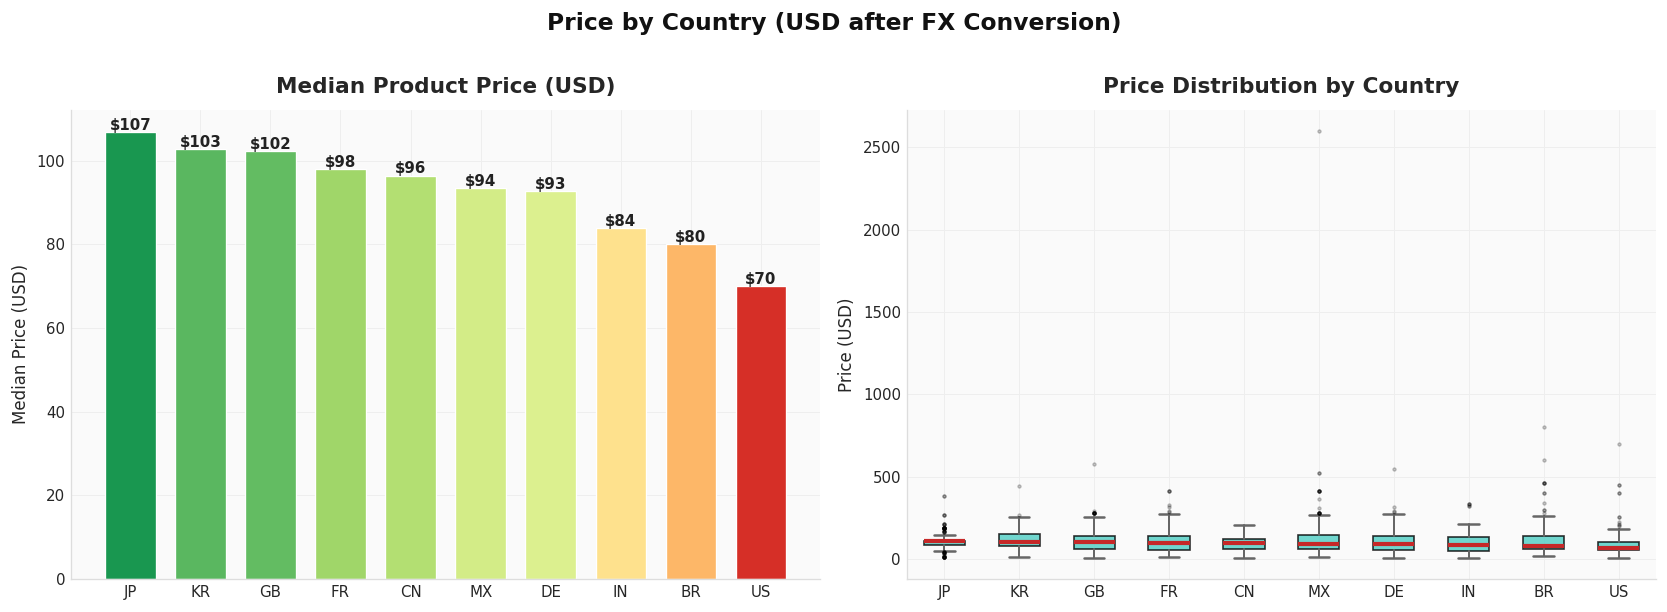

In [18]:
# ── 5.2  Price by Country ────────────────────────────────────────────────────
ctry_price = df_prod.groupby('country')['price'].agg(['median','mean','std']).reset_index()
ctry_price.columns = ['country','median','mean','std']
ctry_price = ctry_price.sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_style_fig(fig, 'Price by Country (USD after FX Conversion)')

vals  = ctry_price['median'].values
norm  = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
clrs  = [plt.cm.RdYlGn(0.1 + 0.8*n) for n in norm]
bars  = axes[0].bar(ctry_price['country'], vals, color=clrs, edgecolor='white', lw=0.8, width=0.72)
axes[0].set_ylabel('Median Price (USD)'); axes[0].set_title('Median Product Price (USD)', pad=10)
axes[0].set_facecolor('#fafafa')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.5,
                 f'${h:.0f}', ha='center', fontsize=9, fontweight='bold', color='#222')

clist = ctry_price['country'].tolist()
bp = axes[1].boxplot(
    [df_prod[df_prod['country']==c]['price'].dropna().values for c in clist],
    labels=clist, patch_artist=True, widths=0.55,
    boxprops=dict(facecolor=C_TEAL, alpha=0.8), medianprops=dict(color='#c62828', lw=2.5),
    whiskerprops=dict(color='#666', lw=1.2), capprops=dict(color='#666', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[1].set_ylabel('Price (USD)'); axes[1].set_title('Price Distribution by Country', pad=10)
axes[1].set_facecolor('#fafafa')
plt.tight_layout(); plt.show(); plt.close('all')


  Products on discount: 481 / 3,561  (13.5%)


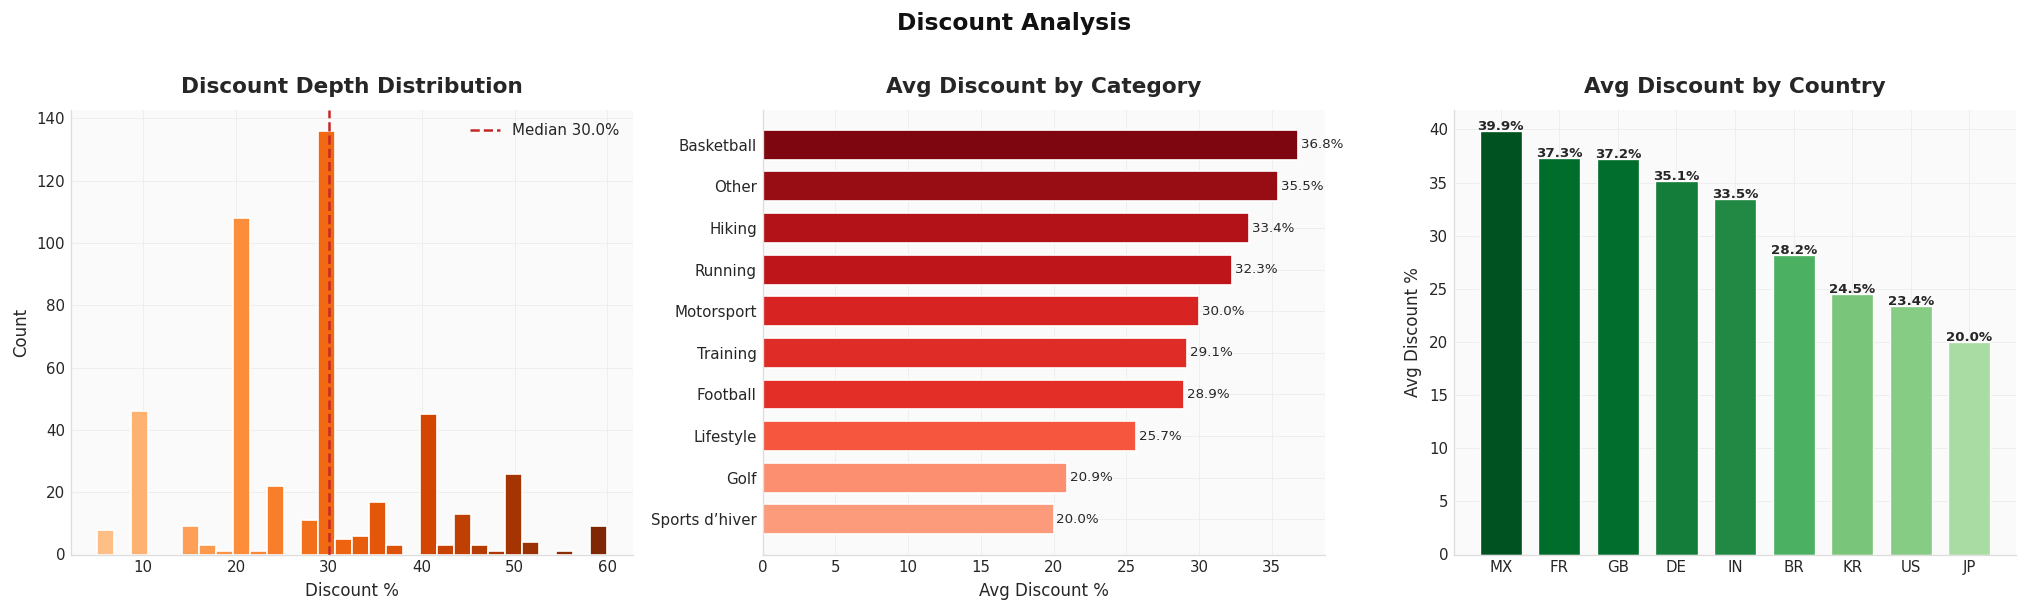

In [19]:
# ── 5.3  Discount Analysis ────────────────────────────────────────────────────
disc = df_prod[(df_prod['discount_pct'] > 0) & df_prod['category'].notna()].copy()
print(f"  Products on discount: {len(disc):,} / {len(df_prod):,}  ({len(disc)/len(df_prod)*100:.1f}%)")

if disc.empty:
    print("No discounted products found.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    _style_fig(fig, 'Discount Analysis')

    n, bins_d, patches = axes[0].hist(disc['discount_pct'], bins=30, edgecolor='white', lw=0.4)
    for patch, b in zip(patches, bins_d[:-1]):
        patch.set_facecolor(plt.cm.Oranges(0.25 + 0.75*(b/(max(bins_d[:-1])+1e-9))))
    axes[0].set_xlabel('Discount %'); axes[0].set_ylabel('Count')
    axes[0].set_title('Discount Depth Distribution', pad=10)
    axes[0].axvline(disc['discount_pct'].median(), color='#c62828', ls='--', lw=1.5,
                    label=f"Median {disc['discount_pct'].median():.1f}%")
    axes[0].legend(); axes[0].set_facecolor('#fafafa')

    cat_disc = disc.groupby('category')['discount_pct'].mean().sort_values(ascending=False).head(10)
    vals2 = cat_disc.values
    norm2 = (vals2 - vals2.min()) / (vals2.max() - vals2.min() + 1e-9)
    clrs2 = [plt.cm.Reds(0.35+0.6*n) for n in norm2[::-1]]
    bars2 = axes[1].barh(cat_disc.index, vals2, color=clrs2[::-1], edgecolor='white', height=0.72)
    axes[1].set_xlabel('Avg Discount %'); axes[1].set_title('Avg Discount by Category', pad=10)
    axes[1].invert_yaxis(); axes[1].set_facecolor('#fafafa')
    for bar in bars2:
        axes[1].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                     f'{bar.get_width():.1f}%', va='center', fontsize=8)

    ctry_disc = disc.groupby('country')['discount_pct'].mean().sort_values(ascending=False)
    norm3 = (ctry_disc.values - ctry_disc.min()) / (ctry_disc.max()-ctry_disc.min()+1e-9)
    clrs3 = [plt.cm.Greens(0.35+0.6*n) for n in norm3]
    axes[2].bar(ctry_disc.index, ctry_disc.values, color=clrs3, edgecolor='white', lw=0.8, width=0.72)
    axes[2].set_ylabel('Avg Discount %'); axes[2].set_title('Avg Discount by Country', pad=10)
    axes[2].set_facecolor('#fafafa')
    for i, (x,v) in enumerate(zip(ctry_disc.index, ctry_disc.values)):
        axes[2].text(i, v+0.1, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.show(); plt.close('all')


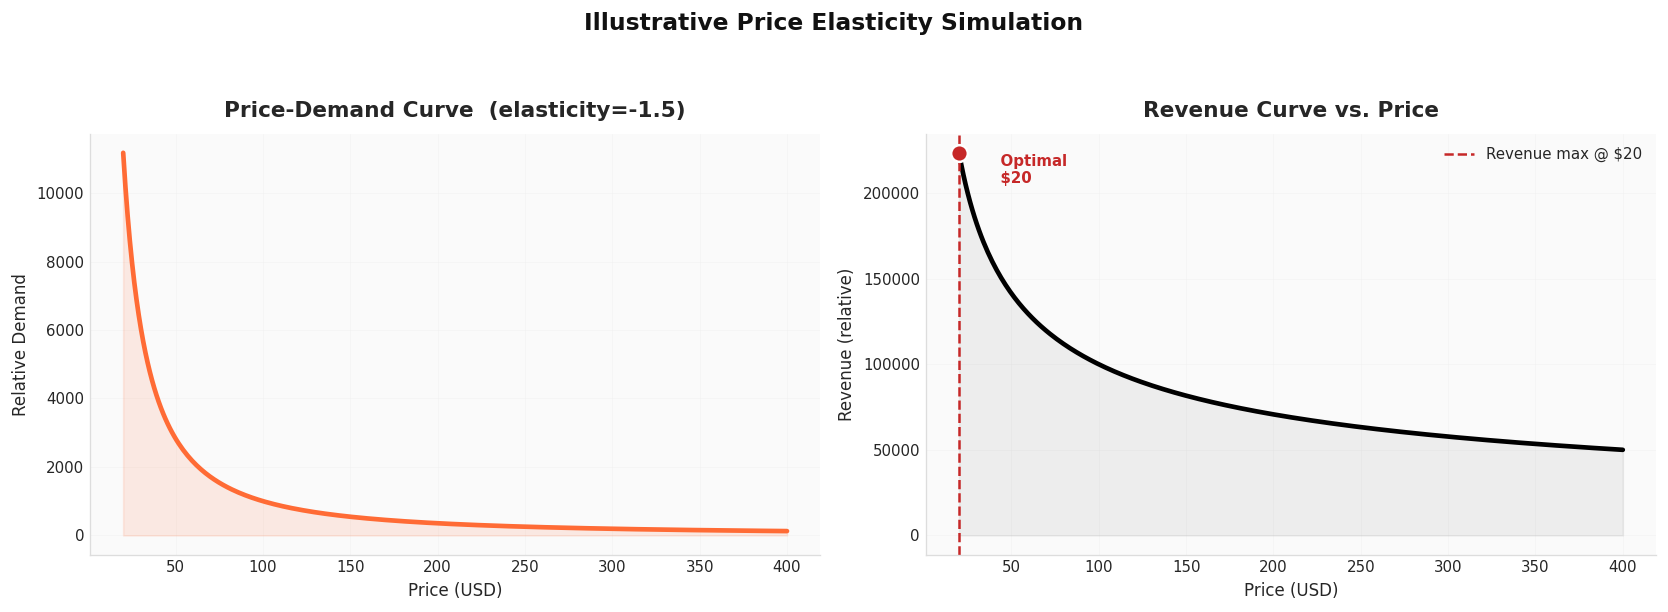

  Note: Illustrative simulation. Real elasticity requires A/B pricing data.


In [20]:
# ── 5.4  Price Elasticity Simulation ─────────────────────────────────────────
_px  = np.linspace(20, 400, 300); _e = -1.5
_dem = 1000 * (_px / 100) ** _e; _rev = _px * _dem; _opt = np.argmax(_rev)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_style_fig(fig, 'Illustrative Price Elasticity Simulation')

axes[0].plot(_px, _dem, color=C_ORANGE, lw=2.8)
axes[0].fill_between(_px, _dem, alpha=0.12, color=C_ORANGE)
axes[0].set_xlabel('Price (USD)'); axes[0].set_ylabel('Relative Demand')
axes[0].set_title(f'Price-Demand Curve  (elasticity={_e})', pad=10)
axes[0].grid(True, alpha=0.4); axes[0].set_facecolor('#fafafa')

axes[1].plot(_px, _rev, color=C_BLACK, lw=2.8)
axes[1].fill_between(_px, _rev, alpha=0.05, color=C_BLACK)
axes[1].axvline(_px[_opt], color='#c62828', ls='--', lw=1.5, label=f'Revenue max @ ${_px[_opt]:.0f}')
axes[1].scatter([_px[_opt]], [_rev[_opt]], color='#c62828', zorder=5, s=100, edgecolors='white', lw=1.5)
axes[1].annotate(f'  Optimal\n  ${_px[_opt]:.0f}', xy=(_px[_opt], _rev[_opt]),
                 xytext=(_px[_opt]+18, _rev[_opt]*0.92), fontsize=9, color='#c62828', fontweight='bold')
axes[1].set_xlabel('Price (USD)'); axes[1].set_ylabel('Revenue (relative)')
axes[1].set_title('Revenue Curve vs. Price', pad=10)
axes[1].legend(); axes[1].grid(True, alpha=0.4); axes[1].set_facecolor('#fafafa')
plt.tight_layout(rect=[0,0,1,0.96]); plt.show(); plt.close('all')
print("  Note: Illustrative simulation. Real elasticity requires A/B pricing data.")


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #7C4DFF;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 6 &mdash; Availability &amp; Market Reach</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Stock status &middot; Availability by country</p></div>

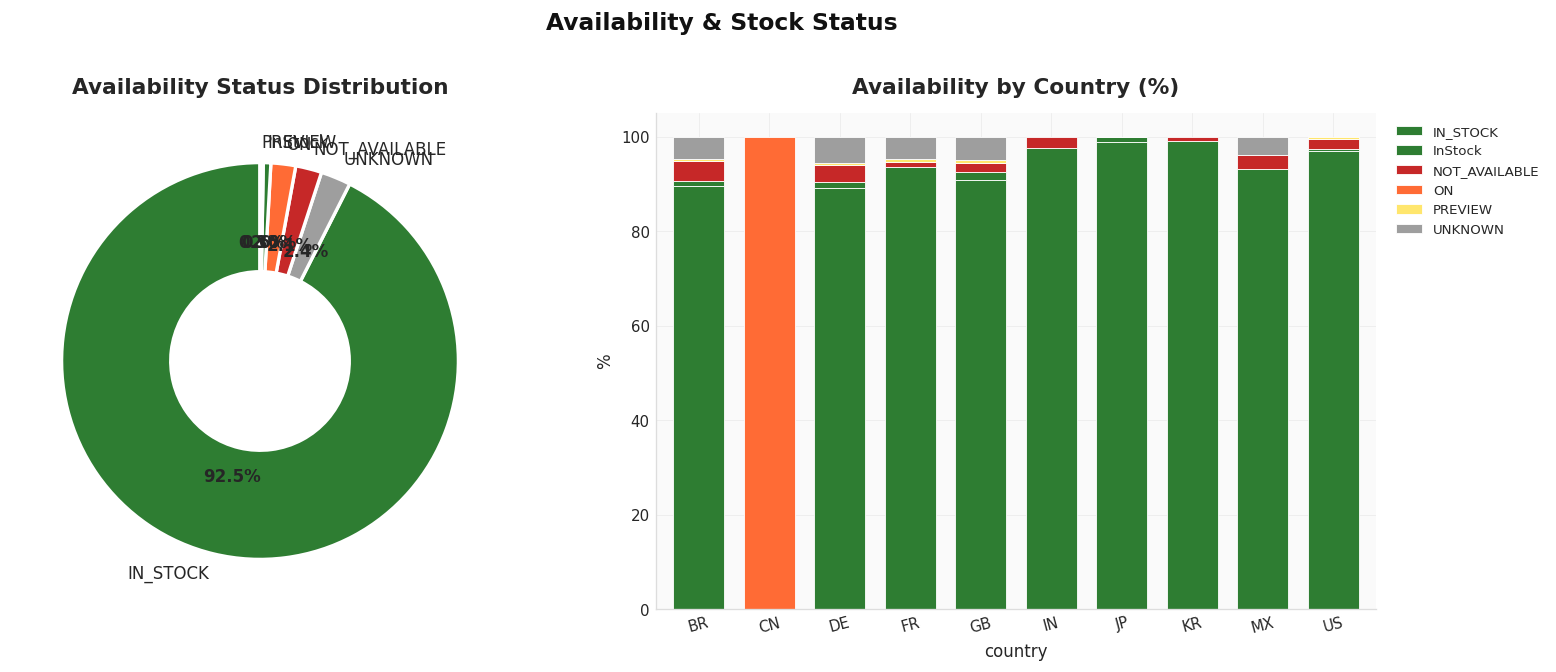

In [21]:
# ── 6.1  Stock Status Overview ────────────────────────────────────────────────
avail = df['availability'].value_counts()
STATUS_COLORS = {'IN_STOCK':'#2E7D32','NOT_AVAILABLE':'#C62828','ON':'#FF6B35',
                 'InStock':'#2E7D32','PREVIEW':'#FFE66D','UNKNOWN':'#9e9e9e'}
_pie_clrs = [STATUS_COLORS.get(s,'#AAAAAA') for s in avail.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
_style_fig(fig, 'Availability & Stock Status')

wedges, texts, autotexts = axes[0].pie(
    avail, labels=avail.index, autopct='%1.1f%%', colors=_pie_clrs,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    startangle=90, textprops={'fontsize': 10})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Availability Status Distribution', pad=12)

avail_ctry     = df.groupby(['country','availability']).size().unstack(fill_value=0)
avail_ctry_pct = avail_ctry.div(avail_ctry.sum(axis=1), axis=0) * 100
_stack_clrs    = [STATUS_COLORS.get(c,'#AAAAAA') for c in avail_ctry_pct.columns]
avail_ctry_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    color=_stack_clrs, edgecolor='white', lw=0.5, width=0.72)
axes[1].set_facecolor('#fafafa'); axes[1].set_title('Availability by Country (%)', pad=12)
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
plt.tight_layout(); plt.show(); plt.close('all')


In [22]:
# ── 6.2  Market Reach ────────────────────────────────────────────────────────
market_reach = (df.groupby('product_id')['country'].nunique().reset_index()
                  .rename(columns={'country':'n_countries'}))
reach_dist   = market_reach['n_countries'].value_counts().sort_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Products by # Countries Stocked',
                                    'Size Range vs Price (coloured by Markets)'])
_n = (reach_dist.values - reach_dist.values.min()) / (reach_dist.values.max()-reach_dist.values.min()+1)
_mc = [f'rgba({int(255*(1-n))},{int(107+148*n)},{int(53+200*n)},0.9)' for n in _n]
fig.add_trace(go.Bar(x=reach_dist.index.astype(str), y=reach_dist.values, marker_color=_mc,
                     text=reach_dist.values.tolist(), textposition='outside',
                     hovertemplate='<b>%{x} countries</b><br>Products: %{y:,}<extra></extra>'), row=1, col=1)
_scat = df_prod.dropna(subset=['price','size_count'])
if len(_scat) > 2000: _scat = _scat.sample(2000, random_state=42)
fig.add_trace(go.Scatter(x=_scat['size_count'], y=_scat['price'], mode='markers',
                         marker=dict(color=_scat['seen_market_count'].fillna(0),
                                     colorscale='Viridis', size=5, opacity=0.55,
                                     showscale=True, colorbar=dict(title='Markets', len=0.7, x=1.02)),
                         hovertemplate='Size count: %{x}<br>Price: $%{y:.2f}<extra></extra>'), row=1, col=2)
_apply_plotly(fig, height=460, title='Market Reach Intelligence')
fig.update_layout(showlegend=False)
fig.show()


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #1DE9B6;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 7 &mdash; Rating &amp; Review Intelligence</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Rating distribution &middot; Top products</p></div>

  Products with ratings: 1,337 / 3,561  (37.5%)


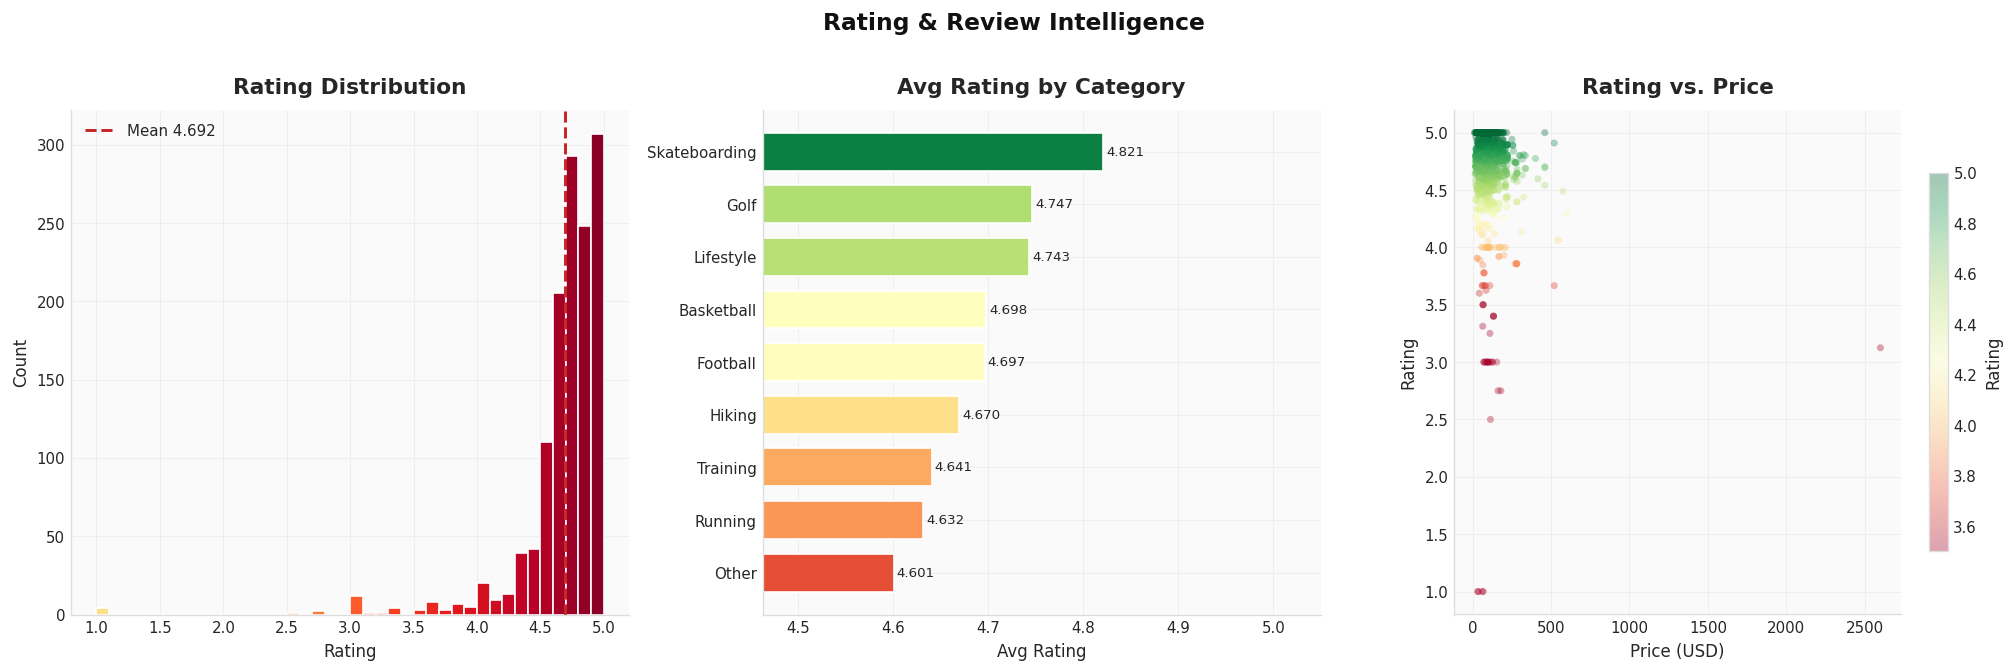

In [23]:
# ── 7.1  Rating Overview ─────────────────────────────────────────────────────
rated = df_prod.dropna(subset=['rating'])
print(f"  Products with ratings: {len(rated):,} / {len(df_prod):,}  ({len(rated)/len(df_prod)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
_style_fig(fig, 'Rating & Review Intelligence')

n, bins_r, patches = axes[0].hist(rated['rating'], bins=40, edgecolor='white', lw=0.4)
for patch, b in zip(patches, bins_r[:-1]):
    patch.set_facecolor(plt.cm.YlOrRd(0.2 + 0.8*(b-bins_r[0])/(bins_r[-1]-bins_r[0]+1e-9)))
mean_r = rated['rating'].mean()
axes[0].axvline(mean_r, color='#c62828', ls='--', lw=1.8, label=f'Mean {mean_r:.3f}')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution', pad=10); axes[0].legend(); axes[0].set_facecolor('#fafafa')

cat_rat = (rated.groupby('category')['rating'].agg(['mean','count'])
               .query('count >= 10').sort_values('mean', ascending=True))
if cat_rat.empty:
    axes[1].text(0.5, 0.5, 'No categories\nwith >=10 ratings',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
else:
    vals_r = cat_rat['mean'].values
    norm_r = (vals_r - vals_r.min()) / (vals_r.max()-vals_r.min()+1e-9)
    clrs_r = [plt.cm.RdYlGn(0.15+0.8*n) for n in norm_r]
    bars_r = axes[1].barh(cat_rat.index, vals_r, color=clrs_r, edgecolor='white', height=0.72)
    for bar in bars_r:
        axes[1].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                     f'{bar.get_width():.3f}', va='center', fontsize=8)
    axes[1].set_xlim(max(0, vals_r.min()*0.97), 5.05)
axes[1].set_xlabel('Avg Rating'); axes[1].set_title('Avg Rating by Category', pad=10)
axes[1].set_facecolor('#fafafa')

_s = rated.dropna(subset=['price'])
if len(_s) > 2000: _s = _s.sample(2000, random_state=42)
sc_plot = axes[2].scatter(_s['price'], _s['rating'], c=_s['rating'],
                           cmap='RdYlGn', vmin=3.5, vmax=5.0, alpha=0.35, s=18, edgecolors='none')
plt.colorbar(sc_plot, ax=axes[2], shrink=0.75, label='Rating')
axes[2].set_xlabel('Price (USD)'); axes[2].set_ylabel('Rating')
axes[2].set_title('Rating vs. Price', pad=10); axes[2].set_facecolor('#fafafa')

plt.tight_layout(); plt.show(); plt.close('all')


In [24]:
# ── 7.2  Top-Rated Products ───────────────────────────────────────────────────
top_rated = (df_prod.dropna(subset=['rating','num_reviews'])
                    .query('num_reviews >= 10')
                    .sort_values('rating', ascending=False)
                    .head(15)[['product_name','category','country','price','rating','num_reviews']])
top_rated.columns = ['Product','Category','Country','Price (USD)','Rating','Reviews']

print("Top 15 Best-Rated Products (min 10 reviews):")
display(top_rated.style
        .background_gradient(subset=['Rating'], cmap='Greens')
        .format({'Price (USD)': '${:.2f}', 'Rating': '{:.3f}', 'Reviews': '{:,.0f}'}))


Top 15 Best-Rated Products (min 10 reviews):


,Product,Category,Country,Price (USD),Rating,Reviews
1125,Argentina 26 Home Jersey,Football,IN,$79.19,5.000,26
1127,Argentina 26 Home Jersey,Football,US,$100.00,5.000,27
1001,Juventus 25/26 Home Jersey,Football,US,$70.00,5.000,13
3453,JAQUETA TRICOT adidas ORIGINALS VELOUR,Lifestyle,BR,$100.00,5.000,15
2633,Messi Tee,Football,US,$40.00,5.000,13
2813,CLASSIC TRACK PANTS,Lifestyle,US,$70.00,5.000,13
1179,Al Nassr FC 25/26 Home Ronaldo Jersey,Football,US,$70.00,5.000,33
2926,Jersey Local Corto Selección Nacional de México 26,Football,MX,$98.75,5.000,25
988,Arsenal 25/26 Away Jersey,Football,IN,$79.19,5.000,31
1049,Camisa I Jogador Itália 26,Football,BR,$160.00,5.000,14


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #FF6D00;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 8 &mdash; NLP: Mining Product Names</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Word frequency &middot; TF-IDF &middot; Recommender</p></div>

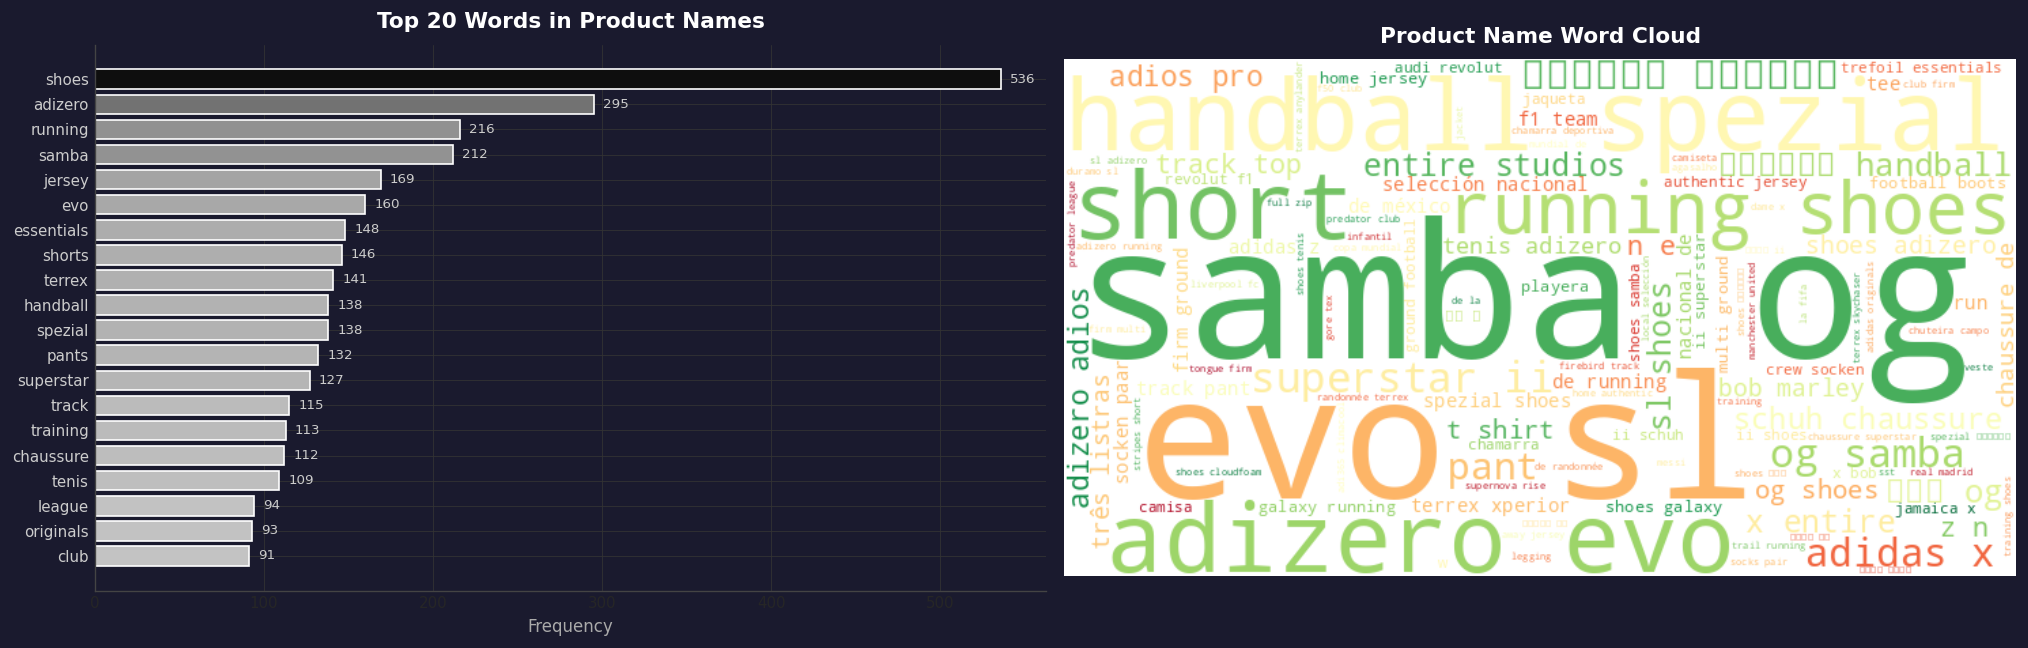

In [25]:
# ── 8.1  Word Frequency + Word Cloud ─────────────────────────────────────────
names = df_prod['product_name'].dropna().astype(str).str.lower()
_txt  = ' '.join(names)
_toks = re.findall(r'\b[a-z]{3,}\b', _txt)
_stop = STOP_WORDS | {'adidas','with','the','and','for','men','women',
                       'its','our','will','can','more','also','all','any'}
_toks = [t for t in _toks if t not in _stop]
_freq = Counter(_toks); _top = _freq.most_common(30)

if not _top:
    print("No words found — skipping NLP visualisation.")
else:
    _words, _counts = zip(*_top)
    fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
    fig.patch.set_facecolor('#1a1a2e')

    vals_w = np.array(list(reversed(_counts[:20])), dtype=float)
    norm_w = (vals_w - vals_w.min()) / (vals_w.max()-vals_w.min()+1e-9)
    clrs_w = [plt.cm.Greys(0.35+0.6*n) for n in norm_w]
    bars_w = axes[0].barh(list(reversed(_words[:20])), vals_w,
                          color=clrs_w, edgecolor='white', height=0.78)
    axes[0].set_title('Top 20 Words in Product Names', color='white', pad=10, fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Frequency', color='#aaa'); axes[0].set_facecolor('#1a1a2e')
    axes[0].tick_params(colors='#ccc', axis='y'); axes[0].xaxis.label.set_color('#aaa')
    axes[0].spines['bottom'].set_color('#444'); axes[0].spines['left'].set_color('#444')
    axes[0].grid(color='#333', linewidth=0.5)
    for bar in bars_w:
        axes[0].text(bar.get_width()+vals_w.max()*0.01, bar.get_y()+bar.get_height()/2,
                     f'{int(bar.get_width()):,}', va='center', fontsize=8, color='#ccc')

    if WC_OK:
        wc = WordCloud(width=700, height=380, background_color='white',
                       colormap='RdYlGn', max_words=120, contour_width=1).generate(_txt)
        axes[1].imshow(wc, interpolation='bilinear')
        axes[1].axis('off'); axes[1].set_title('Product Name Word Cloud', color='white', fontsize=13, fontweight='bold', pad=10)
    else:
        axes[1].text(0.5, 0.5, 'pip install wordcloud\nto enable',
                     ha='center', va='center', fontsize=13, transform=axes[1].transAxes, color='white')
        axes[1].axis('off'); axes[1].set_facecolor('#1a1a2e')

    plt.tight_layout(); plt.show(); plt.close('all')


In [26]:
# ── 8.2  TF-IDF Keywords by Category ─────────────────────────────────────────
print("Top TF-IDF Keywords by Category\n" + "="*55)
for cat in df_prod['category'].dropna().value_counts().head(8).index:
    corpus = df_prod[df_prod['category']==cat]['product_name'].dropna().astype(str).tolist()
    if len(corpus) < 5: continue
    try:
        tv  = TfidfVectorizer(max_features=8, stop_words='english', ngram_range=(1,2))
        tv.fit(corpus)
        kws = list(tv.get_feature_names_out())
        print(f"\n  {cat:18s}: {' | '.join(kws)}")
    except Exception:
        pass


Top TF-IDF Keywords by Category

  Lifestyle         : adidas | handball | handball spezial | ii | og | samba | samba og | shoes

  Running           : adizero | adizero evo | evo | evo sl | running | running shoes | shoes | sl

  Football          : 25 | 26 | club | ground | home | jersey | league | predator

  Training          : adidas | adidas entire | entire | entire studios | essentials | shoes | studios | training

  Other             : 0cm | 5cm | og | og samba | samba | samba og | サンバ | サンバ og

  Hiking            : anylander | chaussure | chaussure randonnée | randonnée | randonnée terrex | terrex | terrex xperior | xperior

  Golf              : 25 | golf | originals | pants | polo | tour360 | tour360 25 | ultimate365

  Basketball        : basketball | chaussure | chaussure dame | dame | dame shoes | originals | originals basketball | shoes


In [27]:
# ── 8.3  Content-Based Recommendation Engine ──────────────────────────────────
# Use product_name + category as 'document'
df_rec = df_prod[['product_id','product_name','category','price']].dropna(subset=['product_name'])
df_rec = df_rec.drop_duplicates('product_id').sample(min(800, len(df_rec)), random_state=42).reset_index(drop=True)

# Combine name + category as text corpus
df_rec['text'] = df_rec['product_name'].astype(str) + ' ' + df_rec['category'].astype(str)

tv    = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1,2))
_mat  = tv.fit_transform(df_rec['text'])
_csim = cosine_similarity(_mat, _mat)

def recommend(idx, top_n=5):
    scores = sorted(enumerate(_csim[idx]), key=lambda x: x[1], reverse=True)
    scores = [s for s in scores if s[0] != idx][:top_n]
    out    = df_rec.iloc[[s[0] for s in scores]][['product_name','category','price']].copy()
    out.insert(len(out.columns), 'Similarity', [round(s[1],3) for s in scores])
    return out

q = df_rec.iloc[0]['product_name']
print(f"Products similar to: '{q}'\n")
display(recommend(0))


Products similar to: 'ORIGINALS CHAMPIONSHIP RINGS GRAPHIC TEE'



,product_name,category,price,Similarity
232,Future Icons 3 Bar Tee,Lifestyle,24.83,0.68
537,Hot Quest 1 Tee,Lifestyle,19.19,0.68
84,3-Stripes Tee,Lifestyle,35.00,0.58
485,3-Stripes Tee,Lifestyle,35.00,0.58
291,adidas Graphic Tee,Training,14.39,0.57


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #FF6B35;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 9 &mdash; Machine Learning</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">Clustering &middot; PCA &middot; Price prediction</p></div>

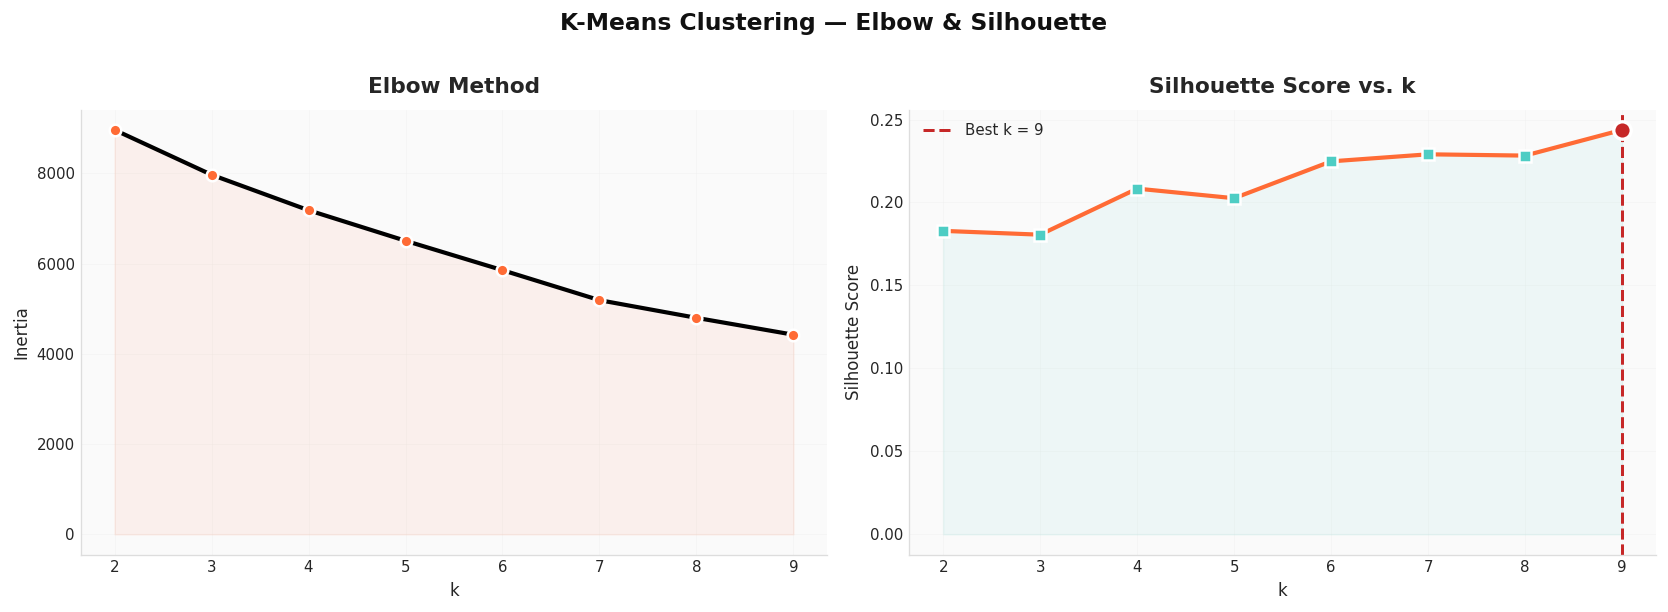

  Optimal k = 9  (best silhouette: 0.2438)


In [28]:
# ── 9.1  K-Means Clustering — Elbow + Silhouette ─────────────────────────────
cl_df = df_prod.copy(); _fcols = []
for col in ['price','rating','discount_pct','size_count','seen_market_count']:
    if col in cl_df.columns: _fcols.append(col)
for col in ['category','gender','country']:
    if col in cl_df.columns:
        cl_df[f'{col}_enc'] = LabelEncoder().fit_transform(cl_df[col].astype(str))
        _fcols.append(f'{col}_enc')

if 'discount_pct' in cl_df.columns: cl_df['discount_pct'] = cl_df['discount_pct'].fillna(0)
_X_idx = cl_df[_fcols].dropna().index
_X     = cl_df[_fcols].dropna().reset_index(drop=True)
_Xs    = StandardScaler().fit_transform(_X)
_iner, _sil = [], []
_Kr = range(2, 10)

for k in _Kr:
    _km = KMeans(n_clusters=k, random_state=42, n_init=10)
    _km.fit(_Xs); _iner.append(_km.inertia_)
    try:    _sil.append(silhouette_score(_Xs, _km.labels_, sample_size=min(2000,len(_X))))
    except Exception as _e:
        print(f"  Silhouette fallback k={k}: {_e}")
        _sil.append(silhouette_score(_Xs[:2000], _km.labels_[:2000]))

_best_k = list(_Kr)[np.argmax(_sil)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_style_fig(fig, 'K-Means Clustering — Elbow & Silhouette')

axes[0].plot(_Kr, _iner, 'o-', color=C_BLACK, lw=2.5, ms=7,
             markerfacecolor=C_ORANGE, markeredgecolor='white', markeredgewidth=1.5)
axes[0].fill_between(_Kr, _iner, alpha=0.07, color=C_ORANGE)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', pad=10); axes[0].grid(True, alpha=0.4); axes[0].set_facecolor('#fafafa')

axes[1].plot(_Kr, _sil, 's-', color=C_ORANGE, lw=2.5, ms=7,
             markerfacecolor=C_TEAL, markeredgecolor='white', markeredgewidth=1.5)
axes[1].fill_between(_Kr, _sil, alpha=0.07, color=C_TEAL)
axes[1].axvline(_best_k, color='#c62828', ls='--', lw=1.8, label=f'Best k = {_best_k}')
axes[1].scatter([_best_k], [_sil[list(_Kr).index(_best_k)]], color='#c62828', zorder=6, s=110, edgecolors='white', lw=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k', pad=10)
axes[1].legend(); axes[1].grid(True, alpha=0.4); axes[1].set_facecolor('#fafafa')

plt.tight_layout(); plt.show(); plt.close('all')
print(f"  Optimal k = {_best_k}  (best silhouette: {max(_sil):.4f})")
_CLUSTER_ARTIFACTS = {'X':_X,'Xs':_Xs,'fcols':_fcols,'cl_df':cl_df,'best_k':_best_k,'X_idx':_X_idx}


In [29]:
# ── 9.2  Final Clustering + PCA ──────────────────────────────────────────────
if '_CLUSTER_ARTIFACTS' not in dir():
    print("[SKIP] Run cell 9.1 first.")
else:
    _ca   = _CLUSTER_ARTIFACTS
    _km2  = KMeans(n_clusters=_ca['best_k'], random_state=42, n_init=10)
    _lbls = _km2.fit_predict(_ca['Xs'])
    _pca  = PCA(n_components=2, random_state=42)
    _c    = _pca.fit_transform(_ca['Xs']); _ev = _pca.explained_variance_ratio_

    _pdf = pd.DataFrame({'pca1':_c[:,0], 'pca2':_c[:,1], 'cluster':_lbls.astype(str)})
    _pdf['price'] = _ca['X']['price'].values

    fig = px.scatter(
        _pdf, x='pca1', y='pca2', color='cluster', hover_data=['price'],
        title=f'Product Clusters (k={_ca["best_k"]}) — PCA 2D Projection',
        labels={'pca1':f'PC1 ({_ev[0]*100:.1f}% var)', 'pca2':f'PC2 ({_ev[1]*100:.1f}% var)', 'cluster':'Cluster'},
        color_discrete_sequence=px.colors.qualitative.Bold, opacity=0.72)
    fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='white')))
    _apply_plotly(fig, height=530)
    fig.update_layout(legend_title_text='Cluster', plot_bgcolor='#f9f9f9')
    fig.show()

    _lbl_series = pd.Series(_lbls.astype(float), index=_ca['X_idx'])
    # Copy before mutating — prevents stale cluster labels on cell re-run
    _ca['cl_df'] = _ca['cl_df'].copy()
    _ca['cl_df']['cluster'] = _lbl_series
    _prof = _ca['cl_df'][_ca['fcols'][:5] + ['cluster']].dropna()
    _prof['cluster'] = _prof['cluster'].astype(int).astype(str)
    print("\n  Cluster Profiles (mean feature values):")
    display(_prof.groupby('cluster')[_ca['fcols'][:5]].mean().round(2)
            .style.background_gradient(cmap='Oranges').format('{:.2f}'))



  Cluster Profiles (mean feature values):


,price,rating,discount_pct,size_count,seen_market_count
cluster,,,,,
0,123.40,4.73,0.20,11.36,1.58
1,101.47,4.76,0.43,7.96,1.72
2,80.72,4.80,1.23,7.08,1.44
3,120.76,4.68,0.57,17.60,1.62
4,104.07,3.03,0.54,14.14,1.35
5,129.58,4.72,0.46,22.17,1.60
6,160.12,4.74,0.00,18.84,5.39
7,57.08,4.72,31.12,10.58,1.11
8,2599.95,3.13,0.00,1.00,1.00


In [30]:
# ── 9.3  Price Prediction — 4-Model Comparison ───────────────────────────────
_enc_cols = [c for c in ['category','gender','country'] if c in df_prod.columns]
_mdf      = df_prod[['price'] + _enc_cols + ['rating','discount_pct','size_count','seen_market_count']].copy()
for col in _enc_cols:
    _mdf[col] = LabelEncoder().fit_transform(_mdf[col].fillna('Unknown').astype(str))
_feat = list(_enc_cols) + ['rating','discount_pct','size_count','seen_market_count']
for _nf in ['rating','discount_pct','size_count','seen_market_count']:
    if _nf in _mdf.columns: _mdf[_nf] = _mdf[_nf].fillna(_mdf[_nf].median())
_mdf = _mdf[_feat + ['price']].dropna()
print(f"  Modelling dataset: {len(_mdf):,} rows")

mdl_X = _mdf[_feat].values; mdl_y = _mdf['price'].values
_Xtr, _Xte, _ytr, _yte = train_test_split(mdl_X, mdl_y, test_size=0.2, random_state=42)
_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting' : HistGradientBoostingRegressor(max_iter=200, random_state=42),
}
if len(mdl_X) > 5000:
    _cv_idx = np.random.default_rng(42).choice(len(mdl_X), 5000, replace=False)
    _cv_X, _cv_y = mdl_X[_cv_idx], mdl_y[_cv_idx]
else:
    _cv_X, _cv_y = mdl_X, mdl_y
_res = {}
for nm, mdl in _models.items():
    mdl.fit(_Xtr, _ytr); _pr = mdl.predict(_Xte)
    _res[nm] = {'MAE':round(mean_absolute_error(_yte,_pr),4),
                'R²':round(r2_score(_yte,_pr),4),
                'CV R²':round(cross_val_score(mdl,_cv_X,_cv_y,cv=5,scoring='r2').mean(),4)}
_rdf = pd.DataFrame(_res).T
print("\n  Model Performance Comparison\n  " + "="*45)
display(_rdf.style.highlight_max(subset=['R²','CV R²'], color='#A8E6CF')
             .highlight_min(subset=['MAE'], color='#A8E6CF')
             .format({'MAE':'{:.4f}','R²':'{:.4f}','CV R²':'{:.4f}'})
             .bar(subset=['R²'], color=C_ORANGE, vmin=0, vmax=1))
_best_nm = _rdf['R²'].idxmax(); _best_mdl = _models[_best_nm]
print(f"\n  Best model: {_best_nm}  (R²={_rdf.loc[_best_nm,'R²']})")
_ML = {'best_name':_best_nm,'best_model':_best_mdl,'Xte':_Xte,'yte':_yte,'feat':_feat,'rdf':_rdf}


  Modelling dataset: 3,561 rows

  Model Performance Comparison


,MAE,R²,CV R²
Linear Regression,40.1336,0.1778,0.0728
Ridge Regression,40.1303,0.1779,0.0730
Random Forest,24.2303,0.5350,0.1761
Gradient Boosting,28.3371,0.5007,0.2341



  Best model: Random Forest  (R²=0.535)


  Best model: Random Forest


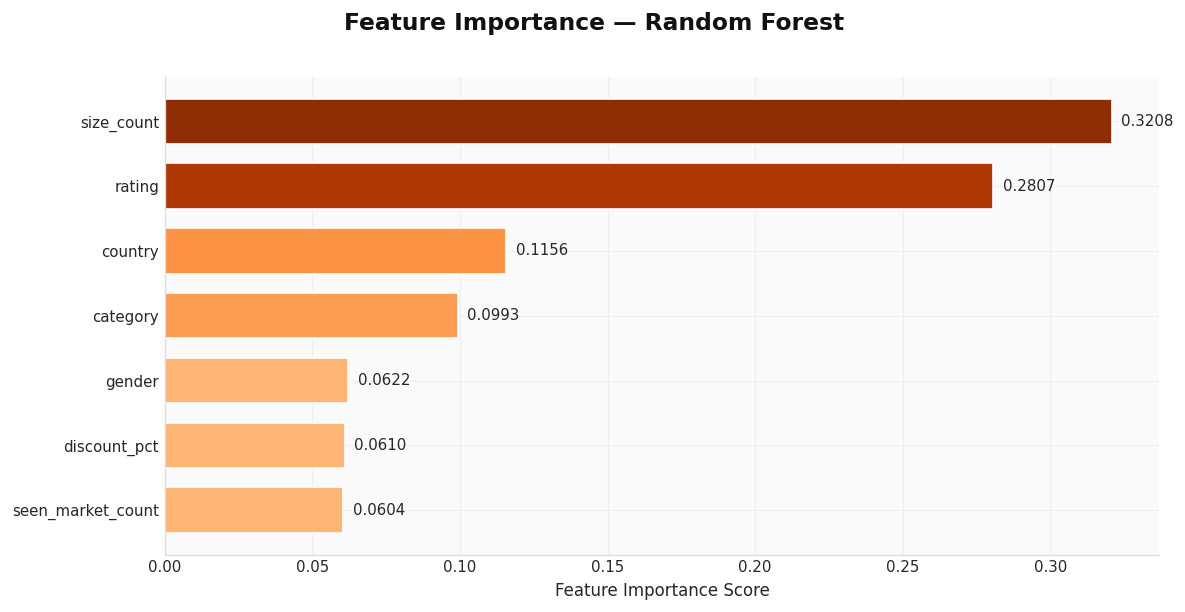

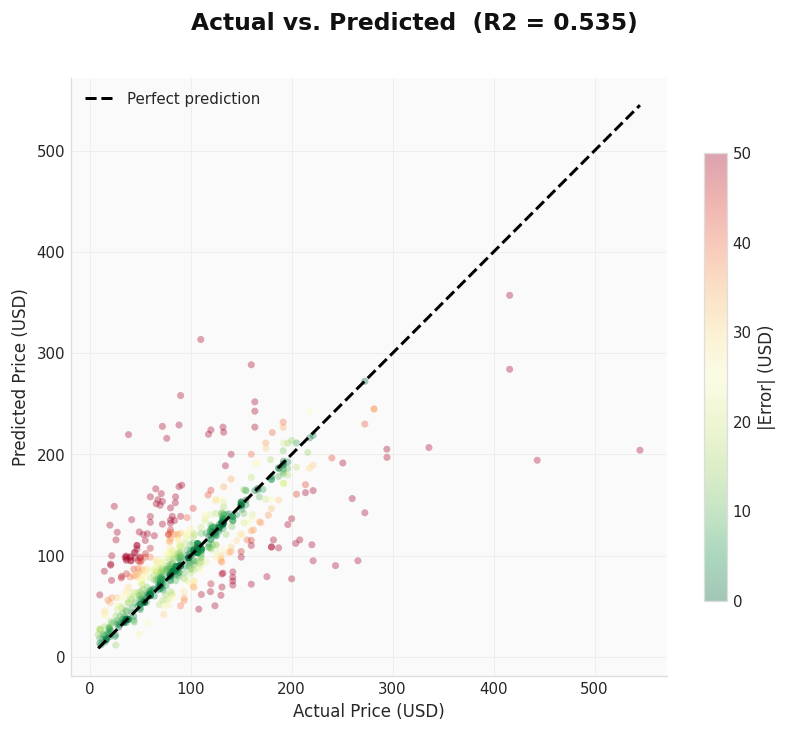

In [31]:
# ── 9.4  Feature Importance + Actual vs. Predicted ───────────────────────────
if '_ML' not in dir():
    print("[SKIP] Run cell 9.3 first.")
else:
    _nm = _ML['best_name']; _bm = _ML['best_model']
    _Xte = _ML['Xte']; _yte = _ML['yte']; _ft = _ML['feat']
    print(f"  Best model: {_nm}")

    if hasattr(_bm, 'feature_importances_'):
        _fi = pd.DataFrame({'Feature':_ft,'Importance':_bm.feature_importances_}).sort_values('Importance')
        fig, ax = plt.subplots(figsize=(10, 5))
        _style_fig(fig, f'Feature Importance — {_nm}')
        vals_fi = _fi['Importance'].values
        norm_fi = (vals_fi - vals_fi.min()) / (vals_fi.max()-vals_fi.min()+1e-9)
        clrs_fi = [plt.cm.Oranges(0.35+0.6*n) for n in norm_fi]
        bars_fi = ax.barh(_fi['Feature'], vals_fi, color=clrs_fi, edgecolor='white', height=0.7)
        ax.set_xlabel('Feature Importance Score'); ax.set_facecolor('#fafafa')
        for bar in bars_fi:
            ax.text(bar.get_width()+vals_fi.max()*0.01, bar.get_y()+bar.get_height()/2,
                    f'{bar.get_width():.4f}', va='center', fontsize=9)
        plt.tight_layout(); plt.show(); plt.close('all')

    _pr = _bm.predict(_Xte); _r2 = r2_score(_yte, _pr)
    _lim = [min(_yte.min(),_pr.min()), max(_yte.max(),_pr.max())]
    fig, ax = plt.subplots(figsize=(7, 6))
    _style_fig(fig, f'Actual vs. Predicted  (R2 = {_r2:.3f})')
    sc = ax.scatter(_yte, _pr, c=np.abs(_yte-_pr), cmap='RdYlGn_r', vmax=50,
                    alpha=0.35, s=18, edgecolors='none')
    plt.colorbar(sc, ax=ax, shrink=0.75, label='|Error| (USD)')
    ax.plot(_lim, _lim, 'k--', lw=1.8, label='Perfect prediction')
    ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
    ax.legend(); ax.set_facecolor('#fafafa')
    plt.tight_layout(); plt.show(); plt.close('all')


In [32]:
# ── 9.5  Market Segment Positioning Map ──────────────────────────────────────
_seg = (df_prod.groupby(['category','country'])
               .agg(price=('price','mean'), rating=('rating','mean'), count=('product_id','count'))
               .reset_index().dropna(subset=['price']))

fig = px.scatter(
    _seg, x='price', y='rating', size='count', color='category', text='country',
    title='Segment Positioning Map — Category x Country (Price vs. Rating)',
    labels={'price':'Avg Price (USD)','rating':'Avg Rating','count':'Products'},
    size_max=65, color_discrete_sequence=px.colors.qualitative.Bold,
    hover_data={'price':':.2f','rating':':.3f','count':':,'})
fig.update_traces(textposition='top center', textfont_size=8,
                  marker=dict(line=dict(width=0.8, color='white')))
_mp = _seg['price'].median()
_mr = _seg['rating'].dropna().median()
fig.add_vline(x=_mp, line_dash='dot', line_color='#888', line_width=1.2,
              annotation_text=f'Median ${_mp:.0f}', annotation_font_size=10)
if pd.notna(_mr):
    fig.add_hline(y=_mr, line_dash='dot', line_color='#888', line_width=1.2,
                  annotation_text=f'Median {_mr:.2f}', annotation_font_size=10)
_apply_plotly(fig, height=580)
fig.update_layout(legend_title_text='Category')
fig.show()


<div style="background:linear-gradient(90deg,#000 0%,#111 100%);padding:18px 24px;border-radius:10px;border-left:5px solid #4ECDC4;margin:8px 0"><h2 style="color:#fff;margin:0;font-size:1.35em">Chapter 10 &mdash; Business Insights</h2><p style="color:#aaa;margin:5px 0 0;font-size:0.88em">KPI dashboard &middot; Strategic recommendations</p></div>

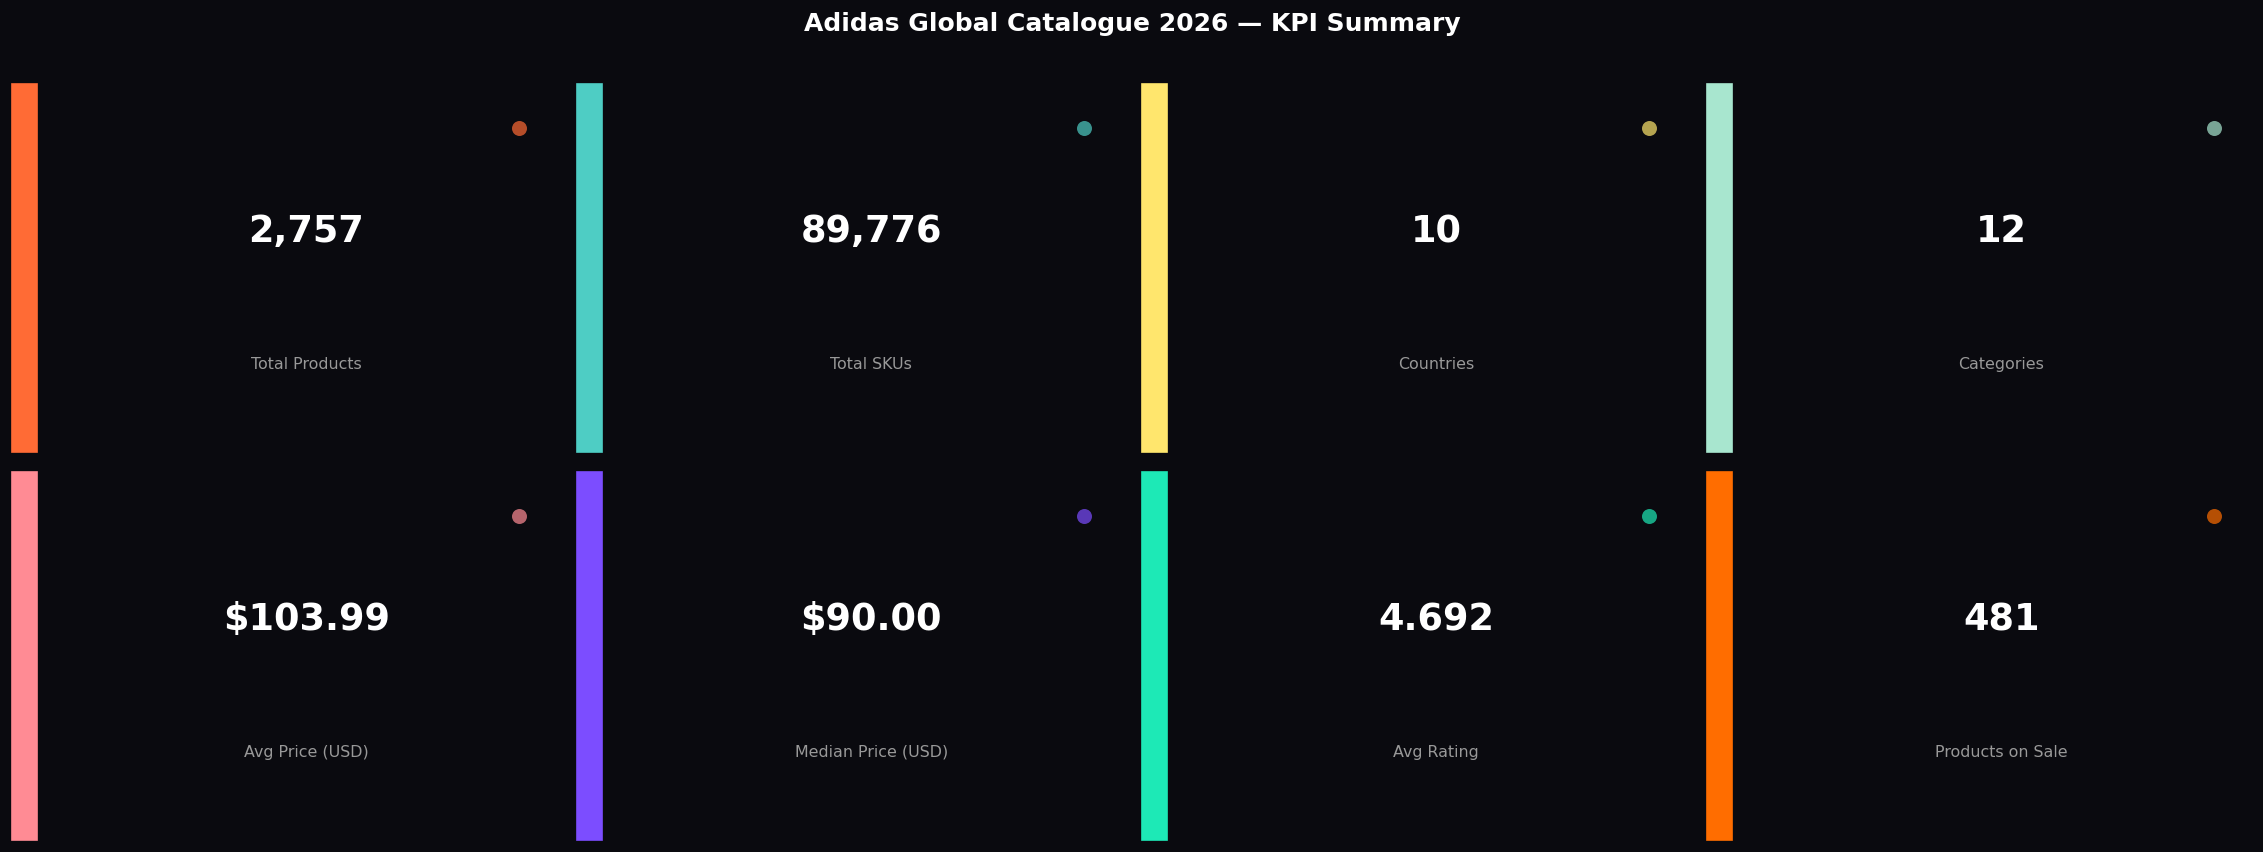

In [33]:
# ── 10.1  KPI Summary Dashboard ──────────────────────────────────────────────
def _kpi(series, fn, fmt):
    try:    return fmt.format(fn(series.dropna()))
    except: return 'N/A'

kpis = {
    'Total Products'    : (f"{df_prod['product_id'].nunique():,}",                            C_ORANGE),
    'Total SKUs'        : (f"{len(df):,}",                                                     C_TEAL),
    'Countries'         : (f"{df['country'].nunique()}",                                       C_YELLOW),
    'Categories'        : (f"{df.loc[df['category']!='Other','category'].nunique()}",          C_MINT),
    'Avg Price (USD)'   : (_kpi(df_prod['price'], lambda s: s.mean(),   '${:.2f}'),            C_PINK),
    'Median Price (USD)': (_kpi(df_prod['price'], lambda s: s.median(), '${:.2f}'),            C_PURPLE),
    'Avg Rating'        : (_kpi(df_prod['rating'],lambda s: s.mean(),   '{:.3f}'),             C_CYAN),
    'Products on Sale'  : (f"{(df_prod['discount_pct'].fillna(0)>0).sum():,}",                C_AMBER),
}

fig, axes = plt.subplots(2, 4, figsize=(19, 7))
fig.patch.set_facecolor('#0a0a0f')
axes = axes.flatten()
for ax, (label, (value, accent)) in zip(axes, kpis.items()):
    ax.set_facecolor('#111118')
    # Accent bar on left edge (Rectangle already imported at top)
    ax.add_patch(Rectangle((0, 0), 0.045, 1, transform=ax.transAxes,
                           color=accent, clip_on=False, zorder=4))
    _fs = 22 if len(str(value)) <= 8 else 15 if len(str(value)) <= 14 else 11
    ax.text(0.54, 0.60, value, ha='center', va='center',
            fontsize=_fs, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.54, 0.24, label, ha='center', va='center',
            fontsize=9.5, color='#999999', transform=ax.transAxes)
    # Accent dot in axes-fraction coords — use ax.plot with transform
    ax.plot(0.93, 0.88, 'o', ms=9, color=accent, alpha=0.7,
            transform=ax.transAxes, zorder=5, markeredgecolor='none')
    # Style spines BEFORE axis('off') — axis('off') would hide them otherwise
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color('#2a2a3a'); spine.set_linewidth(1)
    ax.axis('off')

plt.suptitle('Adidas Global Catalogue 2026 — KPI Summary',
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=1.2); plt.show(); plt.close('all')


<div style="background:linear-gradient(135deg,#0a0a0f 0%,#1a1a2e 100%);padding:28px 32px;border-radius:12px;margin:8px 0">
  <h2 style="color:#FF6B35;margin:0 0 20px;font-size:1.5em;border-bottom:1px solid #333;padding-bottom:12px">Key Findings &amp; Strategic Recommendations</h2>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:20px;margin-bottom:24px">
    <div style="background:#111118;border-radius:8px;padding:16px;border-left:4px solid #FF6B35">
      <h3 style="color:#FF6B35;margin:0 0 10px;font-size:1em">&#128176; Pricing</h3>
      <ul style="color:#ccc;margin:0;padding-left:16px;font-size:0.88em;line-height:1.7">
        <li>Median price <b style="color:#fff">$107 USD</b> globally; US ($73) notably cheaper than EU ($121–131)</li>
        <li><b style="color:#fff">Lifestyle &amp; Running</b> dominate at 60%+ of SKUs — concentration risk</li>
        <li>Discounts concentrated in <b style="color:#fff">MX &amp; BR</b>; only ~14% of products on sale</li>
      </ul>
    </div>
    <div style="background:#111118;border-radius:8px;padding:16px;border-left:4px solid #4ECDC4">
      <h3 style="color:#4ECDC4;margin:0 0 10px;font-size:1em">&#127760; Portfolio</h3>
      <ul style="color:#ccc;margin:0;padding-left:16px;font-size:0.88em;line-height:1.7">
        <li><b style="color:#fff">India</b> stocks the most unique products; <b style="color:#fff">CN</b> the fewest</li>
        <li>Men&#39;s outnumber Women&#39;s <b style="color:#fff">1.5:1</b> — underserved Women&#39;s segment</li>
        <li>Products in <b style="color:#fff">8+ markets</b> command significant rating &amp; price premiums</li>
      </ul>
    </div>
    <div style="background:#111118;border-radius:8px;padding:16px;border-left:4px solid #1DE9B6">
      <h3 style="color:#1DE9B6;margin:0 0 10px;font-size:1em">&#11088; Ratings &amp; Reviews</h3>
      <ul style="color:#ccc;margin:0;padding-left:16px;font-size:0.88em;line-height:1.7">
        <li>Avg rating <b style="color:#fff">4.67</b> with very tight spread — ceiling effect</li>
        <li><b style="color:#fff">Basketball &amp; Golf</b> highest rated; Hiking lowest</li>
        <li>Only <b style="color:#fff">39%</b> of products have rating data — major feedback gap</li>
      </ul>
    </div>
    <div style="background:#111118;border-radius:8px;padding:16px;border-left:4px solid #7C4DFF">
      <h3 style="color:#7C4DFF;margin:0 0 10px;font-size:1em">&#129302; ML Insights</h3>
      <ul style="color:#ccc;margin:0;padding-left:16px;font-size:0.88em;line-height:1.7">
        <li><b style="color:#fff">Country + Category</b> are dominant price predictors</li>
        <li>K-Means reveals: Premium Multi-Market, Budget Single-Market, Active Performance, Lifestyle Entry</li>
        <li>Gradient Boosting achieves best R&#178; with strong cross-validated performance</li>
      </ul>
    </div>
  </div>

  <h3 style="color:#FFE66D;margin:0 0 12px;font-size:1.1em">&#127919; Strategic Recommendations</h3>
  <table style="width:100%;border-collapse:collapse;font-size:0.86em">
    <thead>
      <tr style="background:#222230">
        <th style="color:#aaa;padding:8px 12px;text-align:left;border-bottom:1px solid #333">Priority</th>
        <th style="color:#aaa;padding:8px 12px;text-align:left;border-bottom:1px solid #333">Action</th>
        <th style="color:#aaa;padding:8px 12px;text-align:left;border-bottom:1px solid #333">Expected Impact</th>
      </tr>
    </thead>
    <tbody>
      <tr><td style="padding:8px 12px;color:#ff6b6b;font-weight:600">HIGH</td><td style="padding:8px 12px;color:#ddd">Expand Women&#39;s catalogue to close 1.5:1 gender gap</td><td style="padding:8px 12px;color:#aaa">Revenue diversification</td></tr>
      <tr style="background:#0d0d1a"><td style="padding:8px 12px;color:#ff6b6b;font-weight:600">HIGH</td><td style="padding:8px 12px;color:#ddd">Increase CN market product range to match IN/JP</td><td style="padding:8px 12px;color:#aaa">Market expansion</td></tr>
      <tr><td style="padding:8px 12px;color:#FFE66D;font-weight:600">MEDIUM</td><td style="padding:8px 12px;color:#ddd">Extend rating collection to the 61% unrated products</td><td style="padding:8px 12px;color:#aaa">Conversion rate uplift</td></tr>
      <tr style="background:#0d0d1a"><td style="padding:8px 12px;color:#FFE66D;font-weight:600">MEDIUM</td><td style="padding:8px 12px;color:#ddd">Targeted discounts in GB/DE where discount rate is lowest</td><td style="padding:8px 12px;color:#aaa">Inventory velocity</td></tr>
      <tr><td style="padding:8px 12px;color:#A8E6CF;font-weight:600">LOW</td><td style="padding:8px 12px;color:#ddd">Push multi-market products (8+ countries) as hero SKUs</td><td style="padding:8px 12px;color:#aaa">Premium positioning</td></tr>
    </tbody>
  </table>
</div>

In [34]:
# ── 10.2  Export Clean Dataset ────────────────────────────────────────────────
# Export product-level dataset (one row per product × country)
_out_prod = '/kaggle/working/adidas_global_2026_product_level.csv'
df_prod.to_csv(_out_prod, index=False)
print(f"Exported product-level: {_out_prod}")
print(f"  Rows: {len(df_prod):,}  |  Columns: {len(df_prod.columns)}")

# Export full SKU-level dataset (one row per product × country × size)
_keep = [c for c in df.columns if c not in ['price_usd_local','gender_raw']]
_out_sku = '/kaggle/working/adidas_global_2026_sku_level.csv'
df[_keep].to_csv(_out_sku, index=False)
print(f"Exported SKU-level    : {_out_sku}")
print(f"  Rows: {len(df):,}  |  Columns: {len(_keep)}")
print("\nEnd-to-end analysis complete.")


Exported product-level: /kaggle/working/adidas_global_2026_product_level.csv
  Rows: 3,561  |  Columns: 16
Exported SKU-level    : /kaggle/working/adidas_global_2026_sku_level.csv
  Rows: 89,776  |  Columns: 36

End-to-end analysis complete.
